In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
#import squidpy as sq
import anndata as ad

import warnings
import squidpy as sq

  
warnings.simplefilter("ignore", category=UserWarning)

warnings.simplefilter("ignore", category=FutureWarning)  

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [2]:
#PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered'
#PATH ='/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.addrelapse'


PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_inc_relapse_webportal.h5ad'

adata=sc.read_h5ad(PATH)

adata.obs.dataset_id.value_counts()

 

dataset_id
nan                           1670528
Reynolds                       270768
Fiskin_AD                      258665
Luc_Psoriasis                  200265
Ganier_BCC                     150893
Ahlers_Dermalsheath             94951
Ma_Psoriasis                    84340
Church_Healthy                  74402
bullous_pemphigoid              53824
Rojahn_AD                       49822
Dunlap_Lupus                    49821
Direder_Keloid                  47256
Greenleaf_AA                    41131
Ji_SCCarcinoma                  34340
Sole-Boldo                      27273
Kersh_Lichen planus             22686
Tabib_SSc                       22486
Ma_SSc                          21283
Ma_Prurigo                      20892
Dobie_Dupuytren                 20052
LocalSSc_Hutchins               18152
Weidmann_Healthy                17922
Jiang_Lyme                      17215
Kim_DRESS                       14655
Bangert_AD                      14493
Deng_Keloid                     11777
S

In [3]:
# exclude transitioning treatment
adata = adata[adata.obs['Sanger patient ID']!="BK21"]

In [4]:
adata

View of AnnData object with n_obs × n_vars = 3370853 × 4993
    obs: 'sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'dataset_id', 'lvl5_annotation', 'Mapping_status', 'scanvi_predictions', 'atlas_status_reynolds', 'atlas_status_simple', 'cell_id', 'x_centroid', 'y_centroid', 'Sanger patient ID', 'Timepoint', 'disease_overall', 'lvl0_new', 'Timepoint2', 'info_id6', 'response', 'all_vs_core', 'tech', 'scanvi_predictions2', 'lvl1_new', 'niche19', 'data_addition', 'fig1a_numbers_scrna', 'fig1_numbers_xenium_without_validation_data', 'Site_status2', 'tmp', 'lvl0'
    uns: 'lvl5_annotation_colors', 'niche19_colors', 'tech_colors'
    obsm: 'X_scanvi', 'X_umap', 'spatial'

In [5]:
adata.obs.all_vs_core.value_counts()

all_vs_core
core       2930059
relapse     440794
Name: count, dtype: int64

In [6]:
adata[adata.obs.data_addition!="new_relapse"].obs["Site_status"].value_counts()

Site_status
Non-lesional                         1330227
Lesional                              526974
Healthy                               202749
3D_Week12                             180311
3D_Lesional_baseline                  153479
Week 12                               140302
PostRx                                 96485
Psoriasis_replicate_non-lesional       76048
Remission_longterm (past)              75050
Remission_longterm (never)             74463
Week 8 Psoriasis                       72094
Psoriasis_replicate_Lesional           60647
Psoriasis_replicate_PostRx             49385
Day 14_HF                              30438
Relapse                                25836
Remission_longterm (week 8)            23372
PostRx-Lesional Dupilumab (16 wk)       6694
PostRx-Lesional Dupilumab (1 yr)        4226
Name: count, dtype: int64

In [7]:
adata.obs.Site_status.value_counts()

Site_status
Non-lesional                         1330227
Lesional                              526974
Healthy                               202749
3D_Week12                             180311
3D_Lesional_baseline                  153479
Week 12                               140302
Remission_longterm (past)             140285
Remission_longterm (never)            127032
Relapse                               102198
PostRx                                 96485
Psoriasis_replicate_non-lesional       76048
Week 8 Psoriasis                       72094
Remission_longterm (week 8)            71279
Psoriasis_replicate_Lesional           60647
Psoriasis_replicate_PostRx             49385
Day 14_HF                              30438
PostRx-Lesional Dupilumab (16 wk)       6694
PostRx-Lesional Dupilumab (1 yr)        4226
Name: count, dtype: int64

In [8]:
adata.obs.Site_status.isna().sum()

0

In [9]:
adata[adata.obs.Site_status=="Relapse"].obs.info_id6.value_counts()

info_id6
BK72_Relapse        27877
BK74_Relapse        18584
BK70_Relapse        15111
BK73_Relapse        14790
BK51_wk8 Relapse    14433
BK49_wk8 Relapse    11403
Name: count, dtype: int64

In [10]:
adata.obs.Patient_status.value_counts()


Patient_status
AD                               930543
Healthy                          890036
Psoriasis                        563958
relapse                          242073
nan                              186080
3d_Lesional_baseline             175557
3d_Week12                        158233
Bullous pemphigoid                53824
SCC                               34340
Lichen planus                     22686
Prurigo                           20892
Dupuytren                         20052
Lyme_disease/Erythema migrans     17215
SCLE                              14257
Vitiligo                          11513
PSM                                9781
DLE                                7939
Wound                              7801
irAE                               4073
Name: count, dtype: int64

In [11]:
adata = adata[adata.obs["tech"]=="xenium"].copy()

In [12]:
# adata.obs.Site_status_binary.value_counts()

In [13]:
# [x for x in adata.obs["info_id6"].unique() if "relapse" in x.lower()]

In [14]:
# KEEP = ['BK43', 'BK46', 'BK49', 'BK50', 'BK51']

# vals = adata.obs["info_id6"].astype(str).unique()

# hits = [
#     v for v in vals
#     if any(k in v for k in KEEP)
# ]

# print(hits)


In [15]:
colors_new2 = {
        'Epidermis_basal': "#4a538f",# "#3489f1", #"#000080", #"#f0f8ff", #"#007cfe",#'#4f59a1',  # dark blue
    "Epidermis basal":"#3489f1",# "#000080", #"#f0f8ff", #"#000080",
    
                'Epidermis_mid': '#F0F8FF', # #e3e7eb - GREY
  #  "Epidermis_late": "#4682B4", #"#A52A2A",          # pink
            'Epidermis_late':"#2a2f5c",#"#2a2f5c" ,# "#2e2e2e",#'#b1dae6',  # light blue

   'Epidermis basal_cycling': "#007cfe",  #  e2d8dd   "#505aa1",#"#c590a5" , # '#e0c5d2',
'Epidermis_basal_cycling': "#007cfe", 
'EpidermisInflamm_mid':"#f6e3ec",
        'EpidermisInflamm_late': "#800020",
    
    
    # 'Epidermis_Inflammatory': '#f2e7ed',
        "Epidermis_APChi": "#ff1493",
    'Papillary_dermis':"#FFFF00", # "#f6d17a", # yellow
    
  #  'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
    'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
    'Sweat_gland': '#008080',  # dark grey
        'Sweat_gland_channel': "#adf7e8", #'#008080',  # original - 40E0D0
    'Muscle': "#f371af",  # very dark red
    'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
     'Hypodermis': "#FFFFF0", #"#D2B48C",#' # yello  # white = '#ffffff',
    'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
    'Perineural': '#0A0A0A',  # almost black
   # 'Plasma+pDC': '#808080',  # bright turquoise
    #'Sweat gland channel': '#000000',  # black
    #'KC_immunecell': '#FF1493',  # dark pink
    
   # 'Epidermis_late': '#b1dae6',
    "Nonspecific":"#D3D3D3",
     'Reticular_dermis': '#d0e1f2',

 'Large_BV': '#660000',
 'Small_BV': "#c43f40",#'#D96B6B',
     'Tzone-like': "#845DAE",# '#F4D1A1',

 'Sebaceous_gland': "#FFD9A3",      #  "#FFB347",#"#94cb72",#'#e28743',
"Sebaceous_immune": "#ff6145", 
 #'Plasma_cell_niche': "#1F51FF", #"#FFB300",#"#40E0D0",#'#ff5e00',
   # 'Plasma_cell_rich':  "#8080B2", #"
"Plasma_cell_rich": "#04D9FF",
    'HF_Perineural': '#00FF00',
    "OuterHF": "#006600",# 
 'Sebaceous duct': '#e28743',


"Lymphoid Tzone-like": "#825bac",
    



     #007FFF
    "Reticular_dermis_LE_rich" : "#6A8ED8",
        "Reticular_dermis_LErich" : "#6A8ED8",
    "Small_BV_Trich": "#FFB6C1",          # neon orange
    "Tzone-like_Theavy": "#B19CD9",       # light purple
    #"Reticular dermis_F2/F3hi": "#35476C", #"#FF5F1F",# light blue
    "HF_outer": "#90c670",                # very dark green
    "VenuleMuscle": "#B34A7E",

    "Sebaceous_duct": "#FFA07A",          # light orange (salmony)
    "VenuleEndothelium": "#8B0000",       # dark red
    "HF_inner": "#90EE90",                 # light green
    "HF_TNN+COCH+hi": "#39FF14",          # neon green
    # "Peri_sweat_gland": "#d9f9f7",
    'HF_innermost':  "#D95D54",
  #  'Sebaceous_inner_immune':"#F6A85C",
    'Nonspecific/folded': "#F0F0F0",
 'nan': '#FAFAFA'
    }

# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(30,30))

# adata.obs['niche17'] =adata.obs['niche17'] .astype('category')
# adata.uns['niche17_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata.obs['niche17'].cat.categories]
    
# sc.pl.umap(adata, 
#            color=["niche17"  ],
#            size=3, 
#            legend_loc="on data", 
#            vmax="p99", 
#            legend_fontsize=12,
#           legend_fontoutline=2,
#            linewidth=0.02,
#            edgecolor='white',
#           )
# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(18,18))


In [16]:
adata.obs.Timepoint2.value_counts()

Timepoint2
nan                             579185
Non-lesional Baseline           246688
Lesional Baseline               219567
Week 12                         140302
Never Lesional                  109568
Relapse                          76362
Week 8 (resolved)                72094
Baseline past lesional           65235
Baseline never lesional          52569
hf_image                         30438
Relapse (past lesional site)     27004
Week 8 past lesional             20903
Name: count, dtype: int64

In [17]:
adata.obs.Timepoint.value_counts()


Timepoint
nan                             579185
Non-lesional Baseline           246688
Lesional Baseline               219567
Week 12                         140302
Never Lesional                  109568
Relapse                          76362
Week 8 (resolved)                72094
Baseline past lesional           65235
Baseline never lesional          52569
hf_image                         30438
Relapse (past lesional site)     27004
Week 8 past lesional             20903
Name: count, dtype: int64

In [18]:
# adata[adata.obs["Timepoint"]=="Week 8 (resolved)"].obs["Sanger patient ID"
#                                                       ].unique()

In [19]:
# KEEP = ['BK50_Past Lesional', 'BK49_Past Lesional wk8 relaspe', 'BK46_Never Lesional', 'BK51_Past Lesional wk8 relaspe', 'BK51_wk8 Relapse', 'BK46_Past Lesional', 'BK43_Past Lesional', 'BK43_Never Lesional', 'BK49_wk8 Relapse', 'BK49_Past Lesional', 'BK49_Never Lesional', 'BK51_Never Lesional', 'BK50_Never Lesional', 'BK51_Past Lesional']
# adata_i = adata[adata.obs["info_id6"].isin(KEEP)].copy()
# adata_i.shape
# adata_i.obs["Site_status"].value_counts()

In [20]:
KEEP = ["Remission_longterm (past)", "Remission_longterm (never)",
        "Relapse", "Remission_longterm (week 8)"]
adata_i = adata[adata.obs["Site_status"].isin(KEEP)].copy()


In [21]:
adata_i.obs["info_id6"].nunique()

29

In [22]:
# lesional = 6
# nonp-lesiaon

In [23]:
adata_i.obs["info_id6"].nunique()

29

In [24]:
adata_i.obs["info_id6"].value_counts()

info_id6
BK72_Relapse                         27877
BK49_Past Lesional                   27387
BK74_Baseline never lesional         24599
BK70_Week 8 past lesional            20903
BK46_Never Lesional                  18754
BK74_Relapse                         18584
BK46_Past Lesional                   18353
BK74_Relapse (past lesional site)    17601
BK74_Baseline past lesional          17381
BK70_Baseline past lesional          16999
BK72_Baseline past lesional          16497
BK51_Never Lesional                  15454
BK70_Relapse                         15111
BK73_Relapse                         14790
BK50_Never Lesional                  14673
BK51_wk8 Relapse                     14433
BK73_Baseline past lesional          14358
BK70_Baseline never lesional         13737
BK49_Never Lesional                  13472
BK49_Past Lesional wk8 relaspe       12682
BK51_Past Lesional                   12627
BK43_Never Lesional                  12110
BK49_wk8 Relapse                     11403
BK

In [25]:
adata_i[adata_i.obs.sample_id=="Sebaceous_duct"].obs.sample_id.value_counts()

Series([], Name: count, dtype: int64)

In [26]:
adata_i[adata_i.obs.sample_id=="BK49_wk8 Relapse"].obs.niche19.value_counts()

niche19
Small_BV                    3157
Epidermis_upper             2039
Epidermis_basal             1968
Papillary_dermis            1107
Reticular_dermis             928
Epidermis_mid                634
Muscle                       473
Sweat_gland_channel          368
Reticular_dermis_LE_rich     265
Large_BV                     194
Sweat_gland                  101
Perineural                    78
Tzone-like                    49
VenuleMuscle                  23
Hypodermis                    19
Name: count, dtype: int64

In [27]:
adata.obs["response"].value_counts()

response
100.00    88991
89.53     79482
94.98     53364
79.14     40442
6.43      40368
93.39     39148
97.40     36288
59.92     29908
Name: count, dtype: int64

In [28]:
adata_i.obs["Timepoint"].value_counts()

Timepoint
Non-lesional Baseline           98422
Relapse                         76362
Never Lesional                  74463
Baseline past lesional          65235
Baseline never lesional         52569
Relapse (past lesional site)    27004
Lesional Baseline               25836
Week 8 past lesional            20903
Name: count, dtype: int64

In [29]:

adata_i.obs["Site_status"].value_counts()

Site_status
Remission_longterm (past)      140285
Remission_longterm (never)     127032
Relapse                        102198
Remission_longterm (week 8)     71279
Name: count, dtype: int64

In [30]:
RENAME = {"Lesional Baseline": "Relapse (week 8)"}
adata_i.obs["Timepoint"]=adata_i.obs["Timepoint"].map(RENAME).fillna(adata_i.obs["Timepoint"])

In [31]:


# # Copy obs to avoid side effects
# obs = adata_i.obs.copy()

# # Ensure categorical (important)
# obs["Timepoint"] = obs["Timepoint"].astype("category")
# obs["niche19"] = obs["niche19"].astype("category")

# # Contingency table: Timepoint × niche19
# ct = pd.crosstab(obs["Timepoint"], obs["niche19"])

# # Convert to proportions per Timepoint
# ct_prop = ct.div(ct.sum(axis=1), axis=0)

# # Ensure column order matches color dict keys
# ct_prop = ct_prop.loc[:, ct_prop.columns]

# # Build color list in column order
# colors = [colors_new2[n] for n in ct_prop.columns]

# # Plot
# fig, ax = plt.subplots(figsize=(8, 5))

# ct_prop.plot(
#     kind="bar",
#     stacked=True,
#     ax=ax,
#     color=colors,
#     edgecolor="black",
#     linewidth=0.3
# )

# ax.set_xlabel("Timepoint")
# ax.set_ylabel("Proportion of cells")
# ax.set_title("Proportion of niche19 across timepoints")

# ax.legend(
#     title="niche19",
#     bbox_to_anchor=(1.05, 1),
#     loc="upper left",
#     frameon=False
# )

# plt.tight_layout()
# plt.show()

In [32]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Copy obs
# obs = adata_i.obs.copy()

# # Ensure categorical
# obs["Timepoint"] = obs["Timepoint"].astype("category")
# obs["niche19"] = obs["niche19"].astype("category")

# NICHES = ["Sebaceous_immune", "Plasma_cell_rich"]

# # Full contingency table
# ct_all = pd.crosstab(obs["Timepoint"], obs["niche19"])

# # Subset columns of interest
# ct_sub = ct_all[NICHES]

# # Normalize by ALL cells per timepoint
# ct_prop = ct_sub.div(ct_all.sum(axis=1), axis=0)

# # Colors
# colors = [colors_new2[n] for n in ct_prop.columns]

# # Plot
# fig, ax = plt.subplots(figsize=(3, 4))

# ct_prop.plot(
#     kind="bar",
#     stacked=True,
#     ax=ax,
#     color=colors,
#     edgecolor="black",
#     linewidth=0.3
# )

# ax.set_xlabel("Timepoint")
# ax.set_ylabel("Proportion of all cells")
# ax.set_title("Stopping treatment (relapse)")

# ax.legend(
#     title="niche19",
#     frameon=False
# )

# plt.tight_layout()
# plt.show()
 

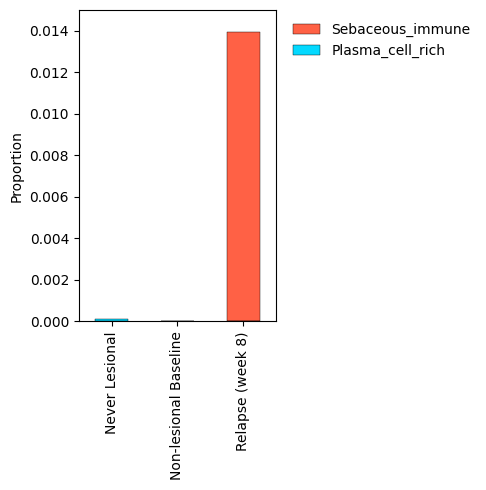

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Copy obs
obs = adata_i.obs.copy()

# Ensure categorical
obs["Timepoint"] = obs["Timepoint"].astype("category")
obs["niche19"] = obs["niche19"].astype("category")

NICHES = ["Sebaceous_immune", "Plasma_cell_rich"]

# Desired x-axis order
ORDER = ["Never Lesional", "Non-lesional Baseline", "Relapse (week 8)"]

# Full contingency table
ct_all = pd.crosstab(obs["Timepoint"], obs["niche19"])

# Reorder rows
ct_all = ct_all.reindex(ORDER)

# Subset columns of interest
ct_sub = ct_all[NICHES]

# Normalize by ALL cells per timepoint
ct_prop = ct_sub.div(ct_all.sum(axis=1), axis=0)

# Colors
colors = [colors_new2[n] for n in ct_prop.columns]

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

ct_prop.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor="black",
    linewidth=0.3
)

# ---------------------------
# Formatting fixes
# ---------------------------

ax.set_ylim(0, 0.015)           # (1)
ax.set_ylabel("Proportion")    # (2)
ax.set_xlabel("")              # (6)

ax.legend(
    frameon=False,             # (5)
    bbox_to_anchor=(1.02, 1),  # (4)
    loc="upper left"
)

ax.set_title("")


plt.tight_layout()
fig.savefig("SUPPLEMENTARY_niches_relapse_hidden.pdf", dpi=300, bbox_inches="tight")
plt.show()

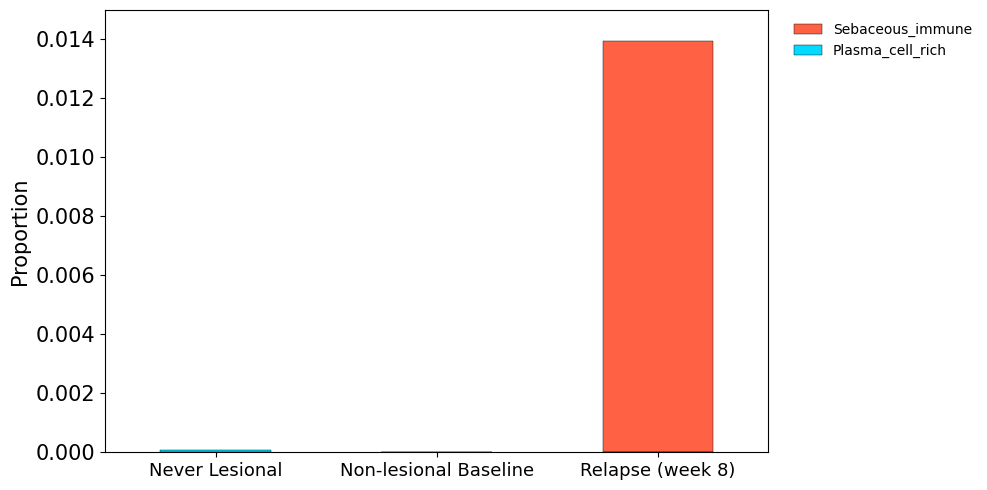

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Copy obs
obs = adata_i.obs.copy()

# Ensure categorical
obs["Timepoint"] = obs["Timepoint"].astype("category")
obs["niche19"] = obs["niche19"].astype("category")

NICHES = ["Sebaceous_immune", "Plasma_cell_rich"]

# Desired x-axis order
ORDER = ["Never Lesional", "Non-lesional Baseline", "Relapse (week 8)"]

# Full contingency table
ct_all = pd.crosstab(obs["Timepoint"], obs["niche19"])

# Reorder rows
ct_all = ct_all.reindex(ORDER)

# Subset columns of interest
ct_sub = ct_all[NICHES]

# Normalize by ALL cells per timepoint
ct_prop = ct_sub.div(ct_all.sum(axis=1), axis=0)

# Colors
colors = [colors_new2[n] for n in ct_prop.columns]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ct_prop.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor="black",
    linewidth=0.3
)

# ---------------------------
# Formatting fixes
# ---------------------------

ax.set_ylim(0, 0.015)           # (1)
ax.set_ylabel("Proportion", fontsize=15)    # (2)
ax.set_xlabel("")              # (6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=13)
ax.tick_params(axis="y", labelsize=15)


ax.legend(
    frameon=False,             # (5)
    bbox_to_anchor=(1.02, 1),  # (4)
    loc="upper left"
)

ax.set_title("")


plt.tight_layout()
fig.savefig("SUPPLEMENTARY_niches_relapse_hidden_v2.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Copy obs
# obs = adata_i.obs.copy()

# # Ensure categorical
# obs["Timepoint"] = obs["Timepoint"].astype("category")
# obs["niche19"] = obs["niche19"].astype("category")

# NICHES = ["Sebaceous_immune", "Plasma_cell_rich"]

# # Full contingency table
# ct_all = pd.crosstab(obs["Timepoint"], obs["niche19"])

# # Subset columns of interest
# ct_sub = ct_all[NICHES]

# # Normalize by ALL cells per timepoint
# ct_prop = ct_sub.div(ct_all.sum(axis=1), axis=0)

# # Colors
# colors = [colors_new2[n] for n in ct_prop.columns]

# # Plot
# fig, ax = plt.subplots(figsize=(12, 5))

# ct_prop.plot(
#     kind="bar",
#     stacked=True,
#     ax=ax,
#     color=colors,
#     edgecolor="black",
#     linewidth=0.3
# )
# ax.set_xlabel("")
# ax.set_ylabel("Proportion", fontsize=14)
# ax.set_title("")

# ax.legend(
#     title="niche19",
#     frameon=False
# )
# #ax.tick_params(axis="x", rotation=0)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=13)
# ax.tick_params(axis="y", labelsize=14)

# ax.legend(
#     frameon=False,
#     fontsize=14,
#     title=None
# )
# fig.savefig("niches_relapse_hidden_v2.pdf", dpi=300, bbox_inches="tight")

# plt.tight_layout()
# plt.show()



In [36]:
MARKERS = {"CD8/CD4": ['CD8A', "CD4"],
        'Tissue-residency': ['ITGAE', 'CD109', 'ZNF683', 'ENTPD1'],
 'TRM_IL13': [ 'IL13', 'NBAS',# 'CCL17',
         'AREG', 'IL9R', 'PDLIM4', 
         'ZBTB16', 'KLRC4', 'ADGRG1', 'RGS9', 'KRT7', "CCL1", "CCR8" ],
 'TRM_IL17': ['IL17A',
  'IL17F',
  'CXCL13',
  'CCL20',
  'IL23R',
  'RORC',
  'ADAM12',  'LRRN3',
  'MYO7A',
  'IL21',  ],
    'Mixed': ['VDR','IL22', 

  'CTSH',

  'CCR6',
  'IL26', 'PTPN13',
         ],  
       
#  'Tissue-residency\n markers': ['CD8A', 'ITGAE', 'CD109', 'ZNF683', 'ENTPD1'],
#  'TRM_IL13': ['IL22', 'IL13', 'NBAS',# 'CCL17',
#          'AREG', 'IL9R', 'PDLIM4', 'CCR8',
#          'ZBTB16', 'KLRC4', 'ADGRG1', 'RGS9'],
#  'TRM_IL17': ['IL17A',
#   'IL17F',
#   'CXCL13',
#   'CCL20',
#   'IL23R',
#   'RORC',
#   'ADAM12',  'LRRN3',
#   'MYO7A',
#   'IL21',],
#     'Mixed': [

#   'CTSH',
#   'VDR',
#   'CCR6',
#   'IL26'
#          ],
#  'Other': ['PTPN13', #'ITGA1'
#           ],
#  'ITGA1hi': ['ITGA1', 'ZHX2', 'BICD1', 'PRR5L', 'ST8SIA1', 'ZNF407', "KLRG1"],
          }

In [37]:
def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata.var_names]
    return LIST


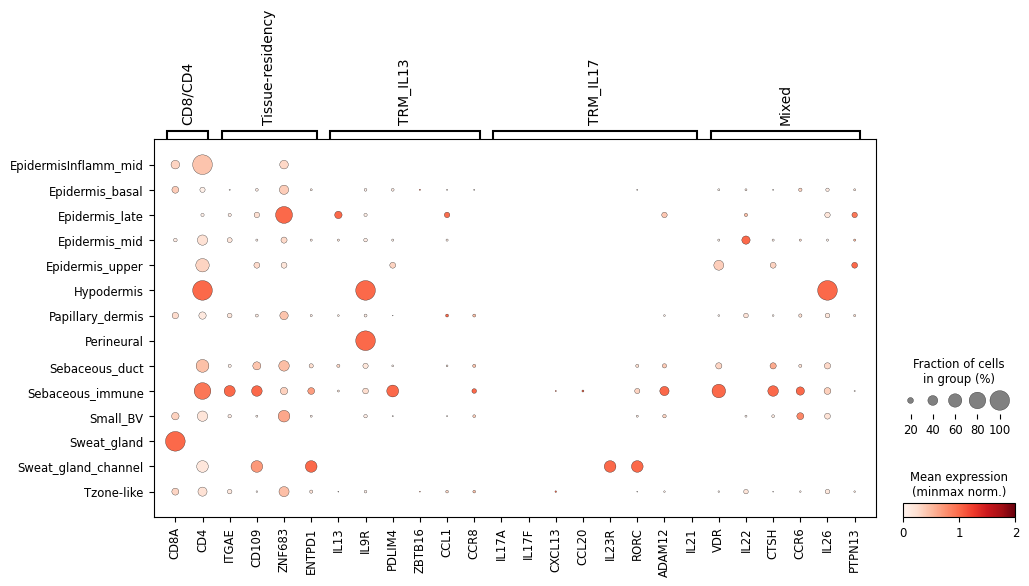

In [38]:
sc.pl.dotplot(
    adata_i[adata_i.obs["scanvi_predictions"]=="TRM_IL13+"],
    remove_markers(MARKERS),
    groupby="niche19",
  standard_scale="var",
    dendrogram=False,
    vmax=2,
    save="relapse_trm_phenotyping.pdf",
                               colorbar_title="Mean expression\n(minmax norm.)",
    #categories_order = ["Merkel cell", "ILC1", "ILC3", "ILC2"],

) 


In [39]:
adata_ii = adata_i[adata_i.obs["niche19"].isin(["Sebaceous_immune", "Tzone-like", "Sebaceous_duct", "Papillary_dermis",
 "Small_BV", "Epidermis_basal", "Sebaceous_gland"])]

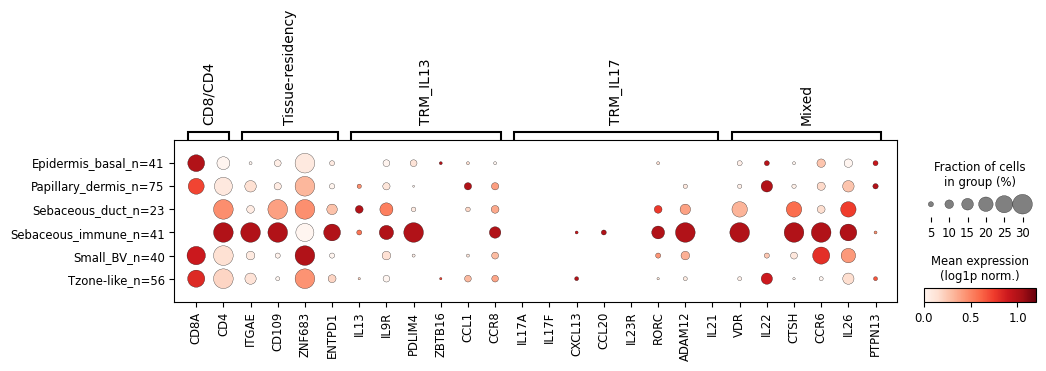

In [40]:
counts = adata_ii[adata_ii.obs["scanvi_predictions"] == "TRM_IL13+"].obs["niche19"].value_counts()
name_map = {k: f"{k}_n={v}" for k, v in counts.items()}

adata_ii.obs["niche19_counts"] = adata_ii.obs["niche19"].map(name_map)

sc.pl.dotplot(
    adata_ii[adata_ii.obs["scanvi_predictions"] == "TRM_IL13+"],
    remove_markers(MARKERS),
    groupby="niche19_counts",
    standard_scale="var",
    dendrogram=False,
    vmax=1.2,
    save="relapse_trm_phenotyping_onlybarplotvalues.pdf",
    colorbar_title="Mean expression\n(log1p norm.)",
    dot_max=0.3,
)

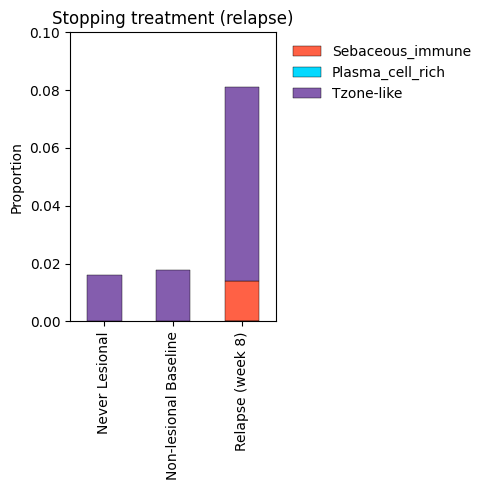

In [41]:
NICHES = ["Sebaceous_immune", "Plasma_cell_rich", "Tzone-like", "Epidermis_APChi"]
NICHES = [x for x in NICHES if x in adata_i.obs["niche19"].unique()]
import pandas as pd

import matplotlib.pyplot as plt

# Copy obs
obs = adata_i.obs.copy()

# Ensure categorical
obs["Timepoint"] = obs["Timepoint"].astype("category")
obs["niche19"] = obs["niche19"].astype("category")


# Desired x-axis order
ORDER = ["Never Lesional", "Non-lesional Baseline", "Relapse (week 8)"]

# Full contingency table
ct_all = pd.crosstab(obs["Timepoint"], obs["niche19"])

# Reorder rows
ct_all = ct_all.reindex(ORDER)

# Subset columns of interest
ct_sub = ct_all[NICHES]

# Normalize by ALL cells per timepoint
ct_prop = ct_sub.div(ct_all.sum(axis=1), axis=0)

# Colors
colors = [colors_new2[n] for n in ct_prop.columns]

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

ct_prop.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor="black",
    linewidth=0.3
)

# ---------------------------
# Formatting fixes
# ---------------------------

ax.set_ylim(0, 0.1)           # (1)
ax.set_ylabel("Proportion")    # (2)
ax.set_xlabel("")              # (6)

ax.legend(
    frameon=False,             # (5)
    bbox_to_anchor=(1.02, 1),  # (4)
    loc="upper left"
)

ax.set_title("Stopping treatment (relapse)")

fig.savefig("niches_remission_all.pdf", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

In [42]:
# adata_i.obs

In [43]:
# Rename
adata_i.obs["Site_status"] = adata_i.obs["Site_status"].cat.rename_categories({
    "Remission_longterm (week 8)": "No disease signs (week 8)"
}) if hasattr(adata_i.obs["Site_status"], "cat") else adata_i.obs["Site_status"].replace({
    "Remission_longterm (week 8)": "No disease signs (week 8)"
})



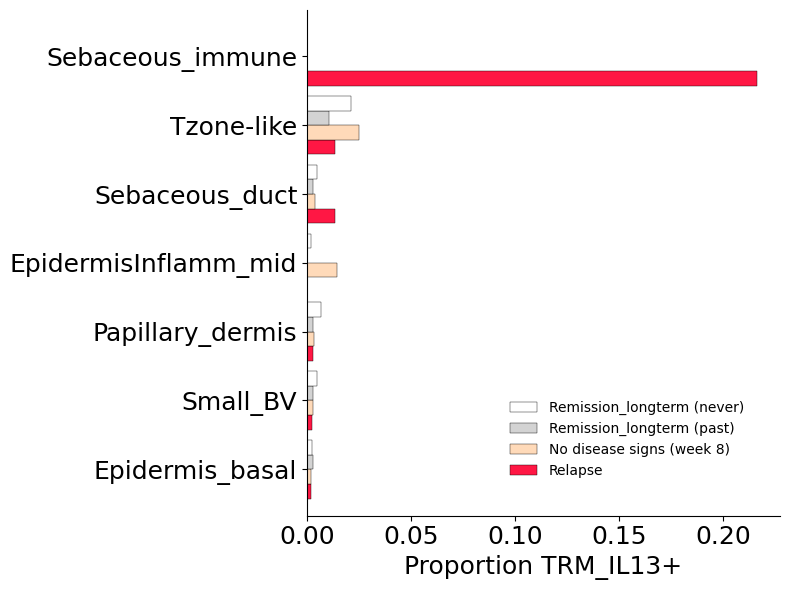

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

total = adata_i.obs.groupby(["niche19", "Site_status"]).size().reset_index(name="total")
trm = adata_i.obs[adata_i.obs["lvl5_annotation"] == "TRM_IL13+"].groupby(["niche19", "Site_status"]).size().reset_index(name="trm")
merged = total.merge(trm, on=["niche19", "Site_status"], how="left")
merged["trm"] = merged["trm"].fillna(0)
merged["proportion"] = merged["trm"] / merged["total"]
props = merged.pivot(index="niche19", columns="Site_status", values="proportion").fillna(0)
props["_mean"] = props.mean(axis=1)
props = props.nlargest(7, "_mean").sort_values("_mean", ascending=True)
props = props.drop(columns="_mean")

colors = {
    "Remission_longterm (never)": "#FFFFFF",
    "Remission_longterm (past)": "#D3D3D3",
    "No disease signs (week 8)": "#FFDAB9",
    "Relapse": "#FF1744",
}

col_order = ["Remission_longterm (never)", "Remission_longterm (past)", "No disease signs (week 8)", "Relapse"]
col_order = col_order[::-1]
props = props[[c for c in col_order if c in props.columns]]
col_colors = [colors[c] for c in props.columns]

fig, ax = plt.subplots(figsize=(8, 6))
props.plot.barh(ax=ax, color=col_colors, edgecolor="black", linewidth=0.3, width=0.85)
ax.tick_params(axis='both', labelsize=18)
ax.set_xlabel("Proportion TRM_IL13+", fontsize=18)
ax.set_ylabel("")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(0.95, 0.05), loc="lower right", frameon=False)

plt.tight_layout()
fig.savefig("4h_barplot_relapse.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [45]:
# print("min err_low:", err_low_w.values.min())
# print("min err_high:", err_high_w.values.min())
# print("any NaN in err_low?", err_low_w.isna().any().any())
# print("any NaN in err_high?", err_high_w.isna().any().any())

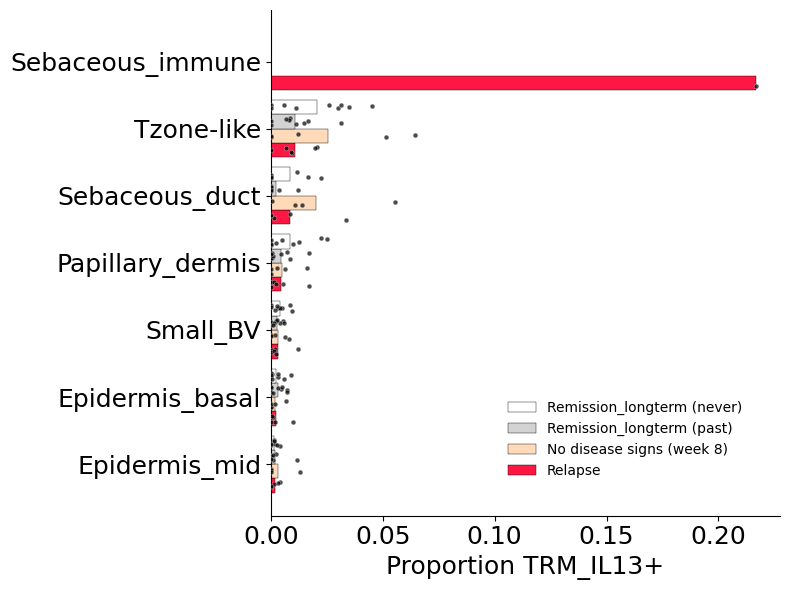

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SAMPLE_COL = "sample_id"   # change to whatever your per-sample column is called

# --- Per-sample proportions (one value per sample × niche × status) ---
total_s = (
    adata_i.obs
    .groupby([SAMPLE_COL, "niche19", "Site_status"])
    .size()
    .reset_index(name="total")
)
trm_s = (
    adata_i.obs[adata_i.obs["lvl5_annotation"] == "TRM_IL13+"]
    .groupby([SAMPLE_COL, "niche19", "Site_status"])
    .size()
    .reset_index(name="trm")
)
per_sample = total_s.merge(trm_s, on=[SAMPLE_COL, "niche19", "Site_status"], how="left")
per_sample["trm"] = per_sample["trm"].fillna(0)
per_sample["proportion"] = per_sample["trm"] / per_sample["total"]

# --- Group-level mean proportions (bar heights) ---
agg = (
    per_sample
    .groupby(["niche19", "Site_status"])["proportion"]
    .mean()
    .reset_index()
)
props = agg.pivot(index="niche19", columns="Site_status", values="proportion").fillna(0)

# Top 7 niches by mean proportion across statuses
props["_mean"] = props.mean(axis=1)
top_niches = props.nlargest(7, "_mean").sort_values("_mean", ascending=True).index
props = props.loc[top_niches].drop(columns="_mean")

# Column ordering
colors = {
    "Remission_longterm (never)":  "#FFFFFF",
    "Remission_longterm (past)":   "#D3D3D3",
    "No disease signs (week 8)":   "#FFDAB9",
    "Relapse":                     "#FF1744",
}
col_order = ["Remission_longterm (never)", "Remission_longterm (past)",
             "No disease signs (week 8)", "Relapse"][::-1]
props = props[[c for c in col_order if c in props.columns]]

# Restrict per_sample to the top niches for the dot overlay
per_sample_top = per_sample[per_sample["niche19"].isin(top_niches)].copy()

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

n_rows = len(props)
n_cols = len(props.columns)
bar_h  = 0.85 / n_cols
y_pos  = np.arange(n_rows)

# Map each niche to its row index, each status to its column position
niche_to_row = {n: i for i, n in enumerate(props.index)}
status_to_idx = {s: i for i, s in enumerate(props.columns)}

for i, col in enumerate(props.columns):
    offsets = y_pos - 0.85/2 + bar_h * (i + 0.5)
    ax.barh(
        offsets, props[col].values,
        height=bar_h,
        color=colors[col], edgecolor="black", linewidth=0.3,
        label=col,
    )

# Overlay per-sample dots
rng = np.random.default_rng(seed=0)
for _, row in per_sample_top.iterrows():
    if row["niche19"] not in niche_to_row or row["Site_status"] not in status_to_idx:
        continue
    row_idx = niche_to_row[row["niche19"]]
    col_idx = status_to_idx[row["Site_status"]]
    # y position = center of this bar + a little jitter so overlapping dots are visible
    y_center = y_pos[row_idx] - 0.85/2 + bar_h * (col_idx + 0.5)
    y_jittered = y_center + rng.uniform(-bar_h * 0.25, bar_h * 0.25)
    ax.scatter(
        row["proportion"], y_jittered,
        color="black", s=12, alpha=0.7, zorder=3,
        edgecolor="white", linewidth=0.3,
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(props.index)
ax.tick_params(axis='both', labelsize=18)
ax.set_xlabel("Proportion TRM_IL13+", fontsize=18)
ax.set_ylabel("")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.set_xlim(left=0)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],
          bbox_to_anchor=(0.95, 0.05), loc="lower right", frameon=False)

plt.tight_layout()
fig.savefig("barplot_relapse_with_dots.pdf", dpi=300, bbox_inches="tight")
plt.show()


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/statsmodels/stats/proportion.py:190: RuntimeWarning: invalid value encountered in divide
  q_ = count_a / nobs_a
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/statsmodels/stats/proportion.py:282: RuntimeWarning: divide by zero encountered in divide
  denom = 1 + crit2 / nobs_a
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/statsmodels/stats/proportion.py:283: RuntimeWarning: divide by zero encountered in divide
  center = (q_ + crit2 / (2 * nobs_a)) / denom
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/statsmodels/stats/proportion.py:285: RuntimeWarning: divide by zero encountered in divide
  q_ * (1.0 - q_) / nobs_a + crit2 / (4.0 * nobs_a**2)


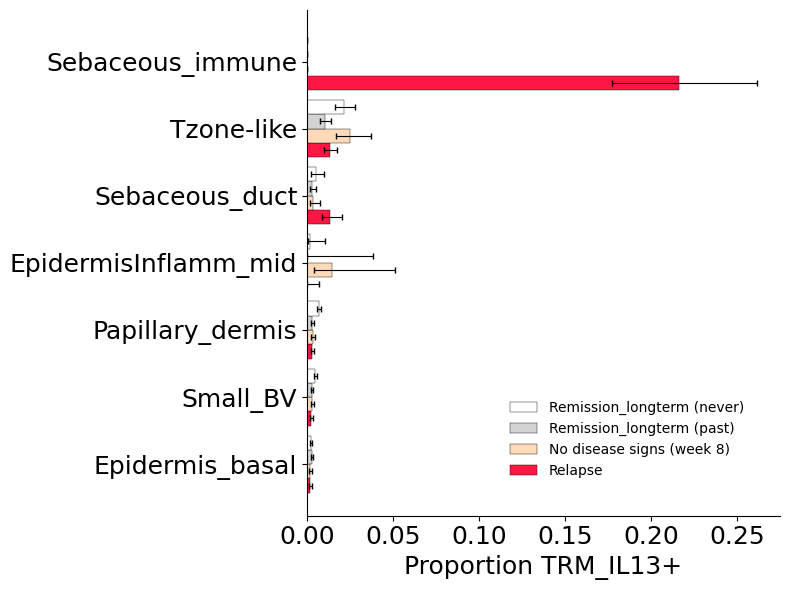

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

# --- Compute proportions and CIs ---
total = adata_i.obs.groupby(["niche19", "Site_status"]).size().reset_index(name="total")
trm = (
    adata_i.obs[adata_i.obs["lvl5_annotation"] == "TRM_IL13+"]
    .groupby(["niche19", "Site_status"])
    .size()
    .reset_index(name="trm")
)
merged = total.merge(trm, on=["niche19", "Site_status"], how="left")
merged["trm"] = merged["trm"].fillna(0).astype(int)
merged["proportion"] = merged["trm"] / merged["total"]

# Wilson 95% confidence intervals
ci_low, ci_high = proportion_confint(
    merged["trm"], merged["total"], alpha=0.05, method="wilson"
)
merged["ci_low"]   = ci_low
merged["ci_high"]  = ci_high
merged["err_low"]  = merged["proportion"] - merged["ci_low"]
merged["err_high"] = merged["ci_high"]   - merged["proportion"]

# --- Pivot to wide form ---
props      = merged.pivot(index="niche19", columns="Site_status", values="proportion").fillna(0)
err_low_w  = merged.pivot(index="niche19", columns="Site_status", values="err_low").fillna(0)
err_high_w = merged.pivot(index="niche19", columns="Site_status", values="err_high").fillna(0)

# Top 7 niches by mean proportion across statuses
props["_mean"] = props.mean(axis=1)
top_niches = props.nlargest(7, "_mean").sort_values("_mean", ascending=True).index

# Apply the top_niches filter to ALL three tables so shapes match
props      = props.loc[top_niches].drop(columns="_mean")
err_low_w  = err_low_w.loc[top_niches].clip(lower=0)
err_high_w = err_high_w.loc[top_niches].clip(lower=0)

# Column ordering
colors = {
    "Remission_longterm (never)":  "#FFFFFF",
    "Remission_longterm (past)":   "#D3D3D3",
    "No disease signs (week 8)":   "#FFDAB9",
    "Relapse":                     "#FF1744",
}
col_order = ["Remission_longterm (never)", "Remission_longterm (past)",
             "No disease signs (week 8)", "Relapse"][::-1]
props      = props[[c for c in col_order if c in props.columns]]
err_low_w  = err_low_w[props.columns]
err_high_w = err_high_w[props.columns]

# Sanity check
assert props.shape == err_low_w.shape == err_high_w.shape, \
    f"shape mismatch: props={props.shape}, err_low={err_low_w.shape}, err_high={err_high_w.shape}"

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

n_rows = len(props)
n_cols = len(props.columns)
bar_h  = 0.85 / n_cols
y_pos  = np.arange(n_rows)

for i, col in enumerate(props.columns):
    offsets   = y_pos - 0.85/2 + bar_h * (i + 0.5)
    xerr_low  = np.clip(err_low_w[col].values,  0, None)
    xerr_high = np.clip(err_high_w[col].values, 0, None)
    ax.barh(
        offsets, props[col].values,
        height=bar_h,
        color=colors[col], edgecolor="black", linewidth=0.3,
        label=col,
        xerr=[xerr_low, xerr_high],
        error_kw={"elinewidth": 0.8, "capsize": 2, "ecolor": "black"},
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(props.index)
ax.tick_params(axis='both', labelsize=18)
ax.set_xlabel("Proportion TRM_IL13+", fontsize=18)
ax.set_ylabel("")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.set_xlim(left=0)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],
          bbox_to_anchor=(0.95, 0.05), loc="lower right", frameon=False)

plt.tight_layout()
fig.savefig("barplot_relapse2.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [48]:
adata_i[adata_i.obs["niche19"]=="Sebaceous_immune"].obs.info_id6.value_counts()

info_id6
BK51_wk8 Relapse    360
Name: count, dtype: int64

In [49]:
adata_i[adata_i.obs["niche19"]=="Sebaceous_immune"].obs.sample_id.value_counts()

sample_id
BK51_wk8 Relapse    360
Name: count, dtype: int64

In [50]:
s

NameError: name 's' is not defined

In [ ]:
adata.obs.Timepoint.value_counts()
 

In [ ]:
KEEP = ['BK50_Past Lesional', 'BK49_Past Lesional wk8 relaspe', 'BK46_Never Lesional', 'BK51_Past Lesional wk8 relaspe', 'BK51_wk8 Relapse', 'BK46_Past Lesional', 'BK43_Past Lesional', 'BK43_Never Lesional', 'BK49_wk8 Relapse', 'BK49_Past Lesional', 'BK49_Never Lesional', 'BK51_Never Lesional', 'BK50_Never Lesional', 'BK51_Past Lesional']
adata_i = adata[~adata.obs["info_id6"].isin(KEEP)].copy()
adata_i=adata_i[adata_i.obs["Patient_status"]=="AD"].copy()
adata_i.obs.Timepoint2.value_counts()


In [ ]:
adata_i.obs.Timepoint.value_counts()


In [ ]:
adata_i=adata_i[adata_i.obs["Timepoint"]!="Day 14_HF"].copy()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Copy obs to avoid side effects
obs = adata_i.obs.copy()

# Ensure categorical (important)
obs["Timepoint"] = obs["Timepoint"].astype("category")
obs["niche19"] = obs["niche19"].astype("category")

# Contingency table: Timepoint × niche19
ct = pd.crosstab(obs["Timepoint"], obs["niche19"])

# Convert to proportions per Timepoint
ct_prop = ct.div(ct.sum(axis=1), axis=0)

# Ensure column order matches color dict keys
ct_prop = ct_prop.loc[:, ct_prop.columns]

# Build color list in column order
colors = [colors_new2[n] for n in ct_prop.columns]

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

ct_prop.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor="black",
    linewidth=0.3
)

ax.set_xlabel("Timepoint")
ax.set_ylabel("Proportion of cells")
ax.set_title("Proportion of niche19 across timepoints")

ax.legend(
    title="niche19",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Copy obs
obs = adata_i.obs.copy()

# Ensure categorical
obs["Timepoint"] = obs["Timepoint"].astype("category")
obs["niche19"] = obs["niche19"].astype("category")

NICHES = ["Sebaceous_immune", "Plasma_cell_rich"]

# Full contingency table
ct_all = pd.crosstab(obs["Timepoint"], obs["niche19"])

# Subset columns of interest
ct_sub = ct_all[NICHES]

# Normalize by ALL cells per timepoint
ct_prop = ct_sub.div(ct_all.sum(axis=1), axis=0)

# Colors
colors = [colors_new2[n] for n in ct_prop.columns]

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

ct_prop.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor="black",
    linewidth=0.3
)
ax.set_xlabel("")
ax.set_ylabel("Proportion", fontsize=14)
ax.set_title("")

ax.legend(
    title="niche19",
    frameon=False
)
#ax.tick_params(axis="x", rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=14)
ax.tick_params(axis="y", labelsize=14)

ax.legend(
    frameon=False,
    fontsize=14,
    title=None
)
fig.savefig("niches_remission_hidden_v2.pdf", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Copy obs
obs = adata_i.obs.copy()

# Ensure categorical
obs["Timepoint"] = obs["Timepoint"].astype("category")
obs["niche19"] = obs["niche19"].astype("category")

NICHES = ["Sebaceous_immune", "Plasma_cell_rich"]

# Desired x-axis order
ORDER = ["Non-lesional Baseline", "Lesional Baseline", "Week 12"]

# Full contingency table
ct_all = pd.crosstab(obs["Timepoint"], obs["niche19"])

# Reorder rows
ct_all = ct_all.reindex(ORDER)

# Subset columns of interest
ct_sub = ct_all[NICHES]

# Normalize by ALL cells per timepoint
ct_prop = ct_sub.div(ct_all.sum(axis=1), axis=0)

# Colors
colors = [colors_new2[n] for n in ct_prop.columns]

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

ct_prop.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor="black",
    linewidth=0.3
)

# ---------------------------
# Formatting fixes
# ---------------------------

ax.set_ylim(0, 0.014)           # (1)
ax.set_ylabel("Proportion")    # (2)
ax.set_xlabel("")              # (6)

ax.legend(
    frameon=False,             # (5)
    bbox_to_anchor=(1.02, 1),  # (4)
    loc="upper left"
)

#ax.set_title("Stopping treatment (relapse)")

fig.savefig("niches_remission_hidden.pdf", dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Copy obs
obs = adata_i.obs.copy()

# Ensure categorical
obs["Timepoint"] = obs["Timepoint"].astype("category")
obs["niche19"] = obs["niche19"].astype("category")

NICHES = ["Sebaceous_immune", "Plasma_cell_rich", "Tzone-like", "Epidermis_APChi"]
NICHES = [x for x in NICHES if x in adata_i.obs["niche19"].unique()]


# Desired x-axis order
ORDER = ["Non-lesional Baseline", "Lesional Baseline", "Week 12"]

# Full contingency table
ct_all = pd.crosstab(obs["Timepoint"], obs["niche19"])

# Reorder rows
ct_all = ct_all.reindex(ORDER)

# Subset columns of interest
ct_sub = ct_all[NICHES]

# Normalize by ALL cells per timepoint
ct_prop = ct_sub.div(ct_all.sum(axis=1), axis=0)

# Colors
colors = [colors_new2[n] for n in ct_prop.columns]

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

ct_prop.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor="black",
    linewidth=0.3
)

# ---------------------------
# Formatting fixes
# ---------------------------

ax.set_ylim(0, 0.1)           # (1)
ax.set_ylabel("Proportion")    # (2)
ax.set_xlabel("")              # (6)

ax.legend(
    frameon=False,             # (5)
    bbox_to_anchor=(1.02, 1),  # (4)
    loc="upper left"
)

#ax.set_title("Stopping treatment (relapse)")

fig.savefig("niches_remission_all.pdf", dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()

In [ ]:
o

In [ ]:
[x for x in adata.obs["sample_id"].unique() if "CE" in x]

In [ ]:
# ['Baseline_resolved_CE6-SKI-28-FO-1-S22-B2' ==  'Baseline_resolved_CE6-SKI-28-FO-4-S22_replicate',
#  'Lesional_CE5-SKI-28-FO-1-S22-A1' ==  'Lesional_CE5-SKI-28-FO-1-S22_replicate',
#  'Baseline_resolved_CE3-SKI-28-FO-1-S22-B1' ==  'Baseline_resolved_CE3-SKI-28-FO-1-S22_replicate',
#  'Baseline_resolved_CE4-SKI-27-FO-1-S22-B2' ==  'Baseline_resolved_CE4-SKI-27-FO-1-S22_replicate',
#  'Lesional_CE6-SKI-28-FO-4-S22-A1' ==  'Lesional_CE6-SKI-28-FO-4-S22_replicate',

#  'Week 8 (resolved)_CE5-SKI-27-FO-4-S22-E1' ==  'Week 8 (resolved)_CE5-SKI-27-FO-4-S22_replicate',
#  'Lesional_CE3-SKI-24-FO-1-S22-A1' ==  'Lesional_Baseline_resolved_CE3-SKI-24-FO-1-S22_replicate',
#  # 'Week 8 (resolved)_CE4-SKI-27-FO-3-S22-E2_a',
#  # 'Week 8 (resolved)_CE3-SKI-28-FO-4-S22-E1_a',
#  # 'Week 8 (resolved)_CE6-SKI-28-FO-3-S22-E2',
 
#   'Week 8 (resolved)_CE4-SKI-27-FO-3-S22-E2_b' ==  'Week 8 (resolved)_CE4-SKI-27-FO-3-S22_replicate',
#  'Week 8 (resolved)_CE3-SKI-28-FO-4-S22-E1_b' ==  'Week 8 (resolved)_CE3-SKI-28-FO-4-S22_replicate',
 
 
#  'Baseline_never_CE4-SKI-21-FO-1-S22-C2' ==  'Baseline_never_CE4-SKI-21-FO-1-S22_replicate'

#  'Baseline_resolved_CE5-SKI-27-FO-1-S22-B1' ==  'Baseline_resolved_CE5-SKI-27-FO-1-S22_replicate',
#  'Baseline_never_CE3-SKI-28-FO-2-S22-C1' ==  'Baseline_never_CE3-SKI-28-FO-2-S22_replicate',
#  'Lesional_CE4-SKI-27-FO-4-S22-A2' ==  'Lesional_CE4-SKI-27-FO-4-S22_replicate',

#  'Baseline_resolved_CE6-SKI-20-FO-1-S22-C2' ==  'Baseline_resolved_CE6-SKI-20-FO-1-S22_replicate',
#  'Week 8 (resolved)_CE6-SKI-28-FO-3-S22_replicate' ==  'Week 8 (resolved)_CE6-SKI-28-FO-3-S22-E2',



#  'Baseline_never_CE5-SKI-27-FO-2-S22-C1' == 'Baseline_never_CE5-SKI-27-FO-2-S22_replicate',







# ]

In [ ]:
# STOP

In [ ]:
# ['Week 8 (resolved)_CE6-SKI-28-FO-3-S22_replicate',
#  'Baseline_never_CE5-SKI-27-FO-2-S22_replicate',
#  'Baseline_resolved_CE3-SKI-28-FO-1-S22_replicate',
#  'Baseline_resolved_CE6-SKI-20-FO-1-S22_replicate',
#  'Lesional_CE6-SKI-28-FO-4-S22_replicate',
#  'Lesional_CE4-SKI-27-FO-4-S22_replicate',
#  'Week 8 (resolved)_CE5-SKI-27-FO-4-S22_replicate',
#  'Baseline_resolved_CE6-SKI-28-FO-4-S22_replicate',
#  'Lesional_CE5-SKI-28-FO-1-S22_replicate',
#  'Baseline_resolved_CE4-SKI-27-FO-1-S22_replicate',
#  'Week 8 (resolved)_CE3-SKI-28-FO-4-S22_replicate',
#  'Week 8 (resolved)_CE4-SKI-27-FO-3-S22_replicate',
#  'Lesional_Baseline_resolved_CE3-SKI-24-FO-1-S22_replicate',
#  'Baseline_never_CE3-SKI-28-FO-2-S22_replicate',
#  'Baseline_resolved_CE5-SKI-27-FO-1-S22_replicate',
#  'Baseline_never_CE4-SKI-21-FO-1-S22_replicate']

In [ ]:
pairs = [
    ("Baseline_resolved_CE6-SKI-28-FO-1-S22-B2",
     "Baseline_resolved_CE6-SKI-28-FO-4-S22_replicate"),

    ("Lesional_CE5-SKI-28-FO-1-S22-A1",
     "Lesional_CE5-SKI-28-FO-1-S22_replicate"),

    ("Baseline_resolved_CE3-SKI-28-FO-1-S22-B1",
     "Baseline_resolved_CE3-SKI-28-FO-1-S22_replicate"),

    ("Baseline_resolved_CE4-SKI-27-FO-1-S22-B2",
     "Baseline_resolved_CE4-SKI-27-FO-1-S22_replicate"),

    ("Lesional_CE6-SKI-28-FO-4-S22-A1",
     "Lesional_CE6-SKI-28-FO-4-S22_replicate"),

    ("Week 8 (resolved)_CE5-SKI-27-FO-4-S22-E1",
     "Week 8 (resolved)_CE5-SKI-27-FO-4-S22_replicate"),

    ("Lesional_CE3-SKI-24-FO-1-S22-A1",
     "Lesional_Baseline_resolved_CE3-SKI-24-FO-1-S22_replicate"),

    ("Week 8 (resolved)_CE4-SKI-27-FO-3-S22-E2_b",
     "Week 8 (resolved)_CE4-SKI-27-FO-3-S22_replicate"),

    ("Week 8 (resolved)_CE3-SKI-28-FO-4-S22-E1_b",
     "Week 8 (resolved)_CE3-SKI-28-FO-4-S22_replicate"),

    ("Baseline_never_CE4-SKI-21-FO-1-S22-C2",
     "Baseline_never_CE4-SKI-21-FO-1-S22_replicate"),

    ("Baseline_resolved_CE5-SKI-27-FO-1-S22-B1",
     "Baseline_resolved_CE5-SKI-27-FO-1-S22_replicate"),

    ("Baseline_never_CE3-SKI-28-FO-2-S22-C1",
     "Baseline_never_CE3-SKI-28-FO-2-S22_replicate"),

    ("Lesional_CE4-SKI-27-FO-4-S22-A2",
     "Lesional_CE4-SKI-27-FO-4-S22_replicate"),

    ("Baseline_resolved_CE6-SKI-20-FO-1-S22-C2",
     "Baseline_resolved_CE6-SKI-20-FO-1-S22_replicate"),

    ("Week 8 (resolved)_CE6-SKI-28-FO-3-S22-E2",
     "Week 8 (resolved)_CE6-SKI-28-FO-3-S22_replicate"),

    ("Baseline_never_CE5-SKI-27-FO-2-S22-C1",
     "Baseline_never_CE5-SKI-27-FO-2-S22_replicate"),
]

In [ ]:
# p_orig

In [ ]:
# p_rep

In [ ]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

rows = []

for orig_id, rep_id in pairs:
    orig = adata.obs[adata.obs["sample_id"] == orig_id]
    rep  = adata.obs[adata.obs["sample_id"] == rep_id]

    if orig.empty or rep.empty:
        print(f"Skipping missing pair: {orig_id}")
        continue

    # Cell-type proportions
    p_orig = orig["lvl5_annotation"].value_counts(normalize=True)
    p_rep  = rep["lvl5_annotation"].value_counts(normalize=True)

    df = (
        p_orig.to_frame("orig")
        .join(p_rep.to_frame("rep"), how="outer")
        .fillna(0)
    )

    if df.shape[0] < 2:
        continue

    r, p = pearsonr(df["orig"], df["rep"])

    rows.append({
        "original": orig_id,
        "replicate": rep_id,
        "r": r,
        "p": p
    })

corr_df = pd.DataFrame(rows).sort_values("r", ascending=False)

In [ ]:
plt.figure(figsize=(20, 20))
plt.scatter(range(len(corr_df)), corr_df["r"], s=60)
plt.axhline(0, color="grey", ls="--", lw=1)

plt.xticks(
    range(len(corr_df)),
    corr_df["original"],
    rotation=90
)

plt.ylabel("Pearson r")
plt.title("Original vs replicate\ncell-type composition agreement")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rows = []

for orig_id, rep_id in pairs:
    orig = adata.obs.loc[
        adata.obs["sample_id"] == orig_id, "lvl5_annotation"
    ]
    rep = adata.obs.loc[
        adata.obs["sample_id"] == rep_id, "lvl5_annotation"
    ]

    if orig.empty or rep.empty:
        continue

    p_orig = orig.value_counts(normalize=True)
    p_rep  = rep.value_counts(normalize=True)

    for ct in adata.obs["lvl5_annotation"].unique():
        rows.append({
            "cell_type": ct,
            "orig_prop": p_orig.get(ct, 0.0),
            "rep_prop":  p_rep.get(ct, 0.0),
            "pair": f"{orig_id} vs {rep_id}"
        })

df = pd.DataFrame(rows)

In [ ]:
df

In [ ]:
plt.figure(figsize=(16, 6))

x_codes = pd.Categorical(df["cell_type"]).codes
x_jitter = x_codes + np.random.uniform(-0.15, 0.15, size=len(df))

y = 1-(df["rep_prop"] - df["orig_prop"]).abs()

plt.scatter(
    x_jitter,
    y,
    s=50,
    alpha=0.6
)

plt.axhline(0, color="grey", ls="--", lw=1)

plt.xticks(
    range(len(pd.unique(df["cell_type"]))),
    pd.unique(df["cell_type"]),
    rotation=90
)

plt.ylabel("Replicate − Original proportion")
plt.title("Per-pair cell-type composition differences")
plt.tight_layout()
plt.show()

In [ ]:
df

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rows = []

for orig_id, rep_id in pairs:
    orig = adata.obs.loc[
        adata.obs["sample_id"] == orig_id, "lvl5_annotation"
    ]
    rep = adata.obs.loc[
        adata.obs["sample_id"] == rep_id, "lvl5_annotation"
    ]

    if orig.empty or rep.empty:
        continue

    p_orig = orig.value_counts(normalize=True)
    p_rep  = rep.value_counts(normalize=True)

    for ct in set(p_orig.index).union(p_rep.index):
        rows.append({
            "cell_type": ct,
            "pair": f"{orig_id} vs rep",
            "delta": p_rep.get(ct, 0.0) - p_orig.get(ct, 0.0)
        })

df = pd.DataFrame(rows)

In [ ]:
plt.figure(figsize=(14, 6))

# jitter x so pairs don't overlap perfectly
x_codes = pd.Categorical(df["cell_type"]).codes
x_jitter = x_codes + np.random.uniform(-0.2, 0.2, size=len(df))

plt.scatter(
    x_jitter,
    df["delta"],
    alpha=0.6,
    s=40
)

plt.axhline(0, color="grey", ls="--", lw=1)

plt.xticks(
    range(len(df["cell_type"].unique())),
    df["cell_type"].unique(),
    rotation=90
)

plt.ylabel("Replicate − Original proportion")
plt.title("Per-pair agreement by cell type")
plt.tight_layout()
plt.show()



In [ ]:
[x for x in adata.obs["sample_id"].unique() if "CE" in x]

In [ ]:
KEEP =  [x for x in adata.obs["sample_id"].unique() if "CE" in x]
adata=adata[adata.obs["sample_id"].isin(KEEP)].copy()
adata.obs["sample_id"].value_counts()

In [ ]:
sc.settings.set_figure_params(dpi=50, dpi_save=600, facecolor="white", frameon=False, figsize=(30,30
                                                                                              ),
                              vector_friendly=True
                             )
for x in [ "Lesional_CE3-SKI-24-FO-1-S22-A1",
     "Lesional_Baseline_resolved_CE3-SKI-24-FO-1-S22_replicate"]:
    
    adata_i = adata[adata.obs["sample_id"]==x].copy()

    SPOT_SIZE=15
    sc.pl.spatial(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        #library_id="spatial",
        #shape=None,
        color="lvl5_annotation",
        spot_size=SPOT_SIZE,
        vmax=1,
        title=x,
        #title=str(STATUS) + "_" + DONOR_ID,
        #title=INFO_ID, #+ "_nonlesional",
    # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12,
        #save=f"fig1b_celltype_legend_600dpi_spotsize{SPOT_SIZE}.pdf"

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )

 

In [ ]:
sc.settings.set_figure_params(dpi=50, dpi_save=600, facecolor="white", frameon=False, figsize=(30,30
                                                                                              ),
                              vector_friendly=True
                             )
for x in ["Lesional_CE4-SKI-27-FO-4-S22-A2",
     "Lesional_CE4-SKI-27-FO-4-S22_replicate"]:
    
    adata_i = adata[adata.obs["sample_id"]==x].copy()

    SPOT_SIZE=15
    sc.pl.spatial(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        #library_id="spatial",
        #shape=None,
        color="lvl5_annotation",
        spot_size=SPOT_SIZE,
        vmax=1,
        #title=str(STATUS) + "_" + DONOR_ID,
        #title=INFO_ID, #+ "_nonlesional",
    # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12,
        #save=f"fig1b_celltype_legend_600dpi_spotsize{SPOT_SIZE}.pdf"

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )

 

In [ ]:
syop

In [ ]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# ----------------------------
# Get replicate samples
# ----------------------------
replicate_mask = adata.obs['sample_id'].str.endswith("_replicate")
replicate_samples = adata.obs.loc[replicate_mask, 'sample_id']

rows = []

for rep in replicate_samples:
    # strip '_replicate'
    prefix = rep.replace("_replicate", "")
    
    # find original sample that starts with this prefix
    orig_candidates = [s for s in adata.obs['sample_id'].unique() if s.startswith(prefix) and not s.endswith("_replicate")]
    
    if len(orig_candidates) == 0:
        print(f"No original found for {rep}")
        continue
    elif len(orig_candidates) > 1:
        # if multiple originals match, take the longest match (most specific)
        orig = max(orig_candidates, key=len)
    else:
        orig = orig_candidates[0]
    
    # subset obs
    orig_obs = adata.obs[adata.obs['sample_id'] == orig]
    rep_obs  = adata.obs[adata.obs['sample_id'] == rep]
    
    # compute cell-type proportions
    orig_props = orig_obs['lvl5_annotation'].value_counts(normalize=True)
    rep_props  = rep_obs['lvl5_annotation'].value_counts(normalize=True)
    
    df = orig_props.to_frame("orig").join(rep_props.to_frame("rep"), how="outer").fillna(0)
    
    if df.shape[0] > 1:
        r, _ = pearsonr(df["orig"], df["rep"])
        rows.append({
            "replicate_sample": rep,
            "original_sample": orig,
            "r": r
        })

# ----------------------------
# DataFrame
# ----------------------------
corr_df = pd.DataFrame(rows).sort_values("r", ascending=False)
print(corr_df)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(10, 4))
plt.scatter(corr_df["replicate_sample"], corr_df["r"], s=50, color="skyblue")
plt.axhline(0, color="grey", linestyle="--", lw=1)
plt.ylabel("Pearson r (cell-type proportions)")
plt.xlabel("Replicate sample")
plt.title("Correlation between replicate and original sample")
plt.xticks(rotation=90)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [ ]:
99

In [ ]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# ----------------------------
# Extract original vs replicate pairs
# ----------------------------
replicate_mask = adata.obs['sample_id'].str.endswith("_replicate")
replicate_samples = adata.obs.loc[replicate_mask, 'sample_id']

rows = []

for rep in replicate_samples:
    # compute base sample (original)
    base_sample = rep.replace("_replicate", "")
    
    # sanity check
    if base_sample not in adata.obs['sample_id'].values:
        print(f"Original missing for {rep}")
        continue
    
    # subset obs
    orig_obs = adata.obs[adata.obs['sample_id'] == base_sample]
    rep_obs  = adata.obs[adata.obs['sample_id'] == rep]
    
    # compute proportions of lvl5_annotation
    orig_props = orig_obs['lvl5_annotation'].value_counts(normalize=True)
    rep_props  = rep_obs['lvl5_annotation'].value_counts(normalize=True)
    
    df = orig_props.to_frame("orig").join(rep_props.to_frame("rep"), how="outer").fillna(0)
    
    if df.shape[0] > 1:
        r, _ = pearsonr(df["orig"], df["rep"])
        rows.append({
            "replicate_sample": rep,
            "original_sample": base_sample,
            "r": r
        })

# ----------------------------
# Convert to DataFrame
# ----------------------------
corr_df = pd.DataFrame(rows).sort_values("r", ascending=False)
print(corr_df)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8, 4))
plt.scatter(corr_df["replicate_sample"], corr_df["r"], s=50, color="skyblue")
plt.axhline(0, color="grey", linestyle="--", lw=1)
plt.ylabel("Pearson r (cell-type proportions)")
plt.xlabel("Replicate sample")
plt.title("Correlation between replicate and original sample")
plt.xticks(rotation=90)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
import re

def base_sample_id(s):
    # remove replicate suffixes
    s = re.sub(r'_replicate$', '', s)
    s = re.sub(r'_[ab]$', '', s)   # _a / _b
    return s

In [ ]:
adata.obs["base_sample"] = adata.obs["sample_id"].apply(base_sample_id)
adata.obs["is_replicate"] = adata.obs["sample_id"].str.contains("replicate|_[ab]$", regex=True)


In [ ]:
print(corr_df)
print(corr_df.columns)
print(len(rows))

In [ ]:
# for base, orig, rep in pairs:
#     print(
#         base,
#         "orig cells:", orig["n_cells"].sum(),
#         "rep cells:",  rep["n_cells"].sum()
#     )

In [ ]:
# pairs = []

# for base, g in prop_df.groupby("base_sample"):
#     samples = g["sample_id"].unique()
#     if len(samples) < 2:
#         continue

#     orig = g[g["is_replicate"] == False]
#     rep  = g[g["is_replicate"] == True]

#     if orig.empty or rep.empty:
#         continue

#     pairs.append((base, orig, rep))
    

In [ ]:
adata.obs["is_replicate"] = adata.obs["sample_id"].str.contains(
    r"(_replicate\b|_[ab]\b)", regex=True
)

In [ ]:
adata.obs["base_sample"] = (
    adata.obs["sample_id"]
    .str.replace(r"_replicate\b", "", regex=True)
    .str.replace(r"_[ab]\b", "", regex=True)
)

In [ ]:
(
    adata.obs[["sample_id", "base_sample", "is_replicate"]]
    .drop_duplicates()
    .sort_values("base_sample")
    .head(30)
)

In [ ]:
adata.obs["is_replicate"].value_counts()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
min_cells = 50  # minimum cells per sample to include

rows = []

# ----------------------------
# Loop over replicate samples
# ----------------------------
for sample, g in adata.obs.groupby("sample_id"):
    if len(g) < min_cells:
        continue  # skip tiny samples

    # split randomly into two halves
    idx = g.index.to_numpy()
    mask = np.random.rand(len(idx)) < 0.5
    idx_a = idx[mask]
    idx_b = idx[~mask]

    if len(idx_a) < min_cells//2 or len(idx_b) < min_cells//2:
        continue

    # compute proportions of lvl5_annotation
    pa = adata.obs.loc[idx_a, "lvl5_annotation"].value_counts(normalize=True)
    pb = adata.obs.loc[idx_b, "lvl5_annotation"].value_counts(normalize=True)

    df = pa.to_frame("a").join(pb.to_frame("b"), how="outer").fillna(0)

    if df.shape[0] > 1:
        r, _ = pearsonr(df["a"], df["b"])
        rows.append({"sample_id": sample, "r": r})

# ----------------------------
# Convert to DataFrame
# ----------------------------
corr_df = pd.DataFrame(rows).sort_values("r", ascending=False)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8, 4))
plt.scatter(corr_df["sample_id"], corr_df["r"], s=50, color="skyblue")
plt.axhline(0, color="grey", linestyle="--", lw=1)
plt.ylabel("Pearson r (cell-type proportions)")
plt.xlabel("Sample")
plt.title("Stability of cell-type composition within replicates")
plt.xticks(rotation=90)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# import pandas as pd

# prop_df = (
#     adata.obs
#     .groupby(["sample_id", "base_sample", "is_replicate", "lvl5_annotation"])
#     .size()
#     .reset_index(name="n_cells")
# )

# prop_df["prop"] = prop_df.groupby("sample_id")["n_cells"].transform(
#     lambda x: x / x.sum()
# )
# prop_df

In [ ]:

pairs = []

for base, g in prop_df.groupby("base_sample"):
    samples = g["sample_id"].unique()
    if len(samples) < 2:
        continue

    orig = g[g["is_replicate"] == False]
    rep  = g[g["is_replicate"] == True]

    if orig.empty or rep.empty:
        continue

    pairs.append((base, orig, rep))
    
rows = []

for base, orig, rep in pairs:
    df = (
        orig[["lvl5_annotation", "prop"]]
        .merge(
            rep[["lvl5_annotation", "prop"]],
            on="lvl5_annotation",
            how="outer",
            suffixes=("_orig", "_rep")
        )
    )

    # ONLY fill numeric columns
    df[["prop_orig", "prop_rep"]] = df[["prop_orig", "prop_rep"]].fillna(0)

    if df.shape[0] > 1:
        r, p = pearsonr(df["prop_orig"], df["prop_rep"])
        rows.append({
            "base_sample": base,
            "r": r,
            "p": p
        })

corr_df = pd.DataFrame(rows)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(corr_df["base_sample"], corr_df["r"], s=50)
plt.axhline(0, color="grey", linestyle="--", lw=1)
plt.ylabel("Pearson r (cell-type proportions)")
plt.xlabel("Sample")
plt.title("Original vs replicate\ncell-type composition agreement")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

min_cells = 10

def compute_corr_per_celltype(
    adata,
    celltype_col,
    group_col,
    group1,
    group2,
    label
):
    rows = []

    for ct in adata.obs[celltype_col].unique():
        adata_ct = adata[adata.obs[celltype_col] == ct]

        n1 = (adata_ct.obs[group_col] == group1).sum()
        n2 = (adata_ct.obs[group_col] == group2).sum()

        if n1 < min_cells or n2 < min_cells:
            continue

        expr1 = adata_ct[adata_ct.obs[group_col] == group1].X.mean(axis=0).A1
        expr2 = adata_ct[adata_ct.obs[group_col] == group2].X.mean(axis=0).A1

        expr_df = pd.DataFrame(
            {group1: expr1, group2: expr2},
            index=adata.var_names
        )

        expr_df = expr_df[(expr_df[group1] != 0) | (expr_df[group2] != 0)]

        if len(expr_df) > 1:
            r, p = pearsonr(expr_df[group1], expr_df[group2])
            rows.append({
                "cell_type": ct,
                "r": r,
                "comparison": label
            })

    return pd.DataFrame(rows)


# 1) Technology comparison
df_tech = compute_corr_per_celltype(
    adata=adata,
    celltype_col="lvl5_annotation",
    group_col="tech",
    group1="scrna",
    group2="xenium",
    label="scrna vs xenium"
)

# 2) Dataset comparison
df_dataset = compute_corr_per_celltype(
    adata=adata,
    celltype_col="lvl5_annotation",
    group_col="dataset_id",
    group1="Reynolds",
    group2="Fiskin_AD",
    label="Reynolds vs Fiskin_AD"
)

# Combine
r_df = pd.concat([df_tech, df_dataset])

plot_df = (
    r_df
    .pivot(index="cell_type", columns="comparison", values="r")
    .dropna()
)

# sort by tech correlation (arbitrary but sane)

plot_df = plot_df.sort_values("scrna vs xenium", ascending=False)


fig, ax = plt.subplots(
    figsize=(7, max(4, 0.35 * len(plot_df)))
)

y = np.arange(len(plot_df))
bar_h = 0.35

ax.barh(
    y - bar_h/2,
    plot_df["scrna vs xenium"],
    height=bar_h,
    label="scrna vs xenium"
)

ax.barh(
    y + bar_h/2,
    plot_df["Reynolds vs Fiskin_AD"],
    height=bar_h,
    label="Reynolds vs Fiskin_AD"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Pearson r (mean gene expression)")
ax.set_title("Expression correlation by cell type")
ax.invert_yaxis()
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# ----------------------------
# Parameters
# ----------------------------
cell_type = "ILC3"  # pick a single cell type
tech1 = "scrna"
tech2 = "xenium"

# ----------------------------
# Subset to cell type
# ----------------------------
adata_ct = adata[adata.obs["lvl5_annotation"] == cell_type].copy()

# ----------------------------
# Aggregate gene expression per technology
# ----------------------------
# Using mean expression across cells for each tech
expr_df = pd.DataFrame({
    tech1: adata_ct[adata_ct.obs["tech"] == tech1].X.mean(axis=0).A1,  # .A1 converts sparse -> 1D
    tech2: adata_ct[adata_ct.obs["tech"] == tech2].X.mean(axis=0).A1
}, index=adata.var_names)

# Drop genes with zero in both techs
expr_df = expr_df[(expr_df[tech1] != 0) | (expr_df[tech2] != 0)]

# ----------------------------
# Compute Pearson correlation
# ----------------------------
r, p = pearsonr(expr_df[tech1], expr_df[tech2])

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(5, 5))
sns.scatterplot(x=tech1, y=tech2, data=expr_df, s=30, alpha=0.7)
sns.regplot(x=tech1, y=tech2, data=expr_df, scatter=False, ci=None, line_kws={"color":"red"})

plt.xlabel(f"Mean expression ({tech1})")
plt.ylabel(f"Mean expression ({tech2})")
plt.title(f"{cell_type} — Pearson r={r:.2f}, p={p:.2e}")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np

# ----------------------------
cell_type = "ILC2"
tech1 = "scrna"
tech2 = "xenium"

adata_ct = adata[adata.obs["lvl5_annotation"] == cell_type].copy()

expr_df = pd.DataFrame({
    tech1: adata_ct[adata_ct.obs["tech"] == tech1].X.mean(axis=0).A1,
    tech2: adata_ct[adata_ct.obs["tech"] == tech2].X.mean(axis=0).A1
}, index=adata.var_names)

# Filter zero-expressed genes
expr_df = expr_df[(expr_df[tech1] != 0) | (expr_df[tech2] != 0)]

# ----------------------------
# Compute correlation
r, p = pearsonr(expr_df[tech1], expr_df[tech2])

# Fit linear regression for residuals
slope, intercept = np.polyfit(expr_df[tech1], expr_df[tech2], 1)
predicted = slope * expr_df[tech1] + intercept
residuals = expr_df[tech2] - predicted

# Define outliers (top 5% absolute residuals)
threshold = np.percentile(np.abs(residuals), 95)
outliers = expr_df[np.abs(residuals) >= threshold]

# ----------------------------
# Plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=tech1, y=tech2, data=expr_df, s=30, alpha=0.7)
sns.regplot(x=tech1, y=tech2, data=expr_df, scatter=False, ci=None, line_kws={"color":"red"})

# Label outliers
for gene in outliers.index:
    plt.text(expr_df.loc[gene, tech1], expr_df.loc[gene, tech2], gene,
             fontsize=8, color="blue")

plt.xlabel(f"Mean expression ({tech1})")
plt.ylabel(f"Mean expression ({tech2})")
plt.title(f"{cell_type} — Pearson r={r:.2f}, p={p:.2e}")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np

# ----------------------------
cell_type = "LC"
tech1 = "scrna"
tech2 = "xenium"

adata_ct = adata[adata.obs["lvl5_annotation"] == cell_type].copy()

expr_df = pd.DataFrame({
    tech1: adata_ct[adata_ct.obs["tech"] == tech1].X.mean(axis=0).A1,
    tech2: adata_ct[adata_ct.obs["tech"] == tech2].X.mean(axis=0).A1
}, index=adata.var_names)

# Filter zero-expressed genes
expr_df = expr_df[(expr_df[tech1] != 0) | (expr_df[tech2] != 0)]

# ----------------------------
# Compute correlation
r, p = pearsonr(expr_df[tech1], expr_df[tech2])

# Fit linear regression for residuals
slope, intercept = np.polyfit(expr_df[tech1], expr_df[tech2], 1)
predicted = slope * expr_df[tech1] + intercept
residuals = expr_df[tech2] - predicted

# Define outliers (top 5% absolute residuals)
threshold = np.percentile(np.abs(residuals), 95)
outliers = expr_df[np.abs(residuals) >= threshold]

# ----------------------------
# Plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=tech1, y=tech2, data=expr_df, s=30, alpha=0.7)
sns.regplot(x=tech1, y=tech2, data=expr_df, scatter=False, ci=None, line_kws={"color":"red"})

# Label outliers
# for gene in outliers.index:
#     plt.text(expr_df.loc[gene, tech1], expr_df.loc[gene, tech2], gene,
#              fontsize=8, color="blue")

plt.xlabel(f"Mean expression ({tech1})")
plt.ylabel(f"Mean expression ({tech2})")
plt.title(f"{cell_type} — Pearson r={r:.2f}, p={p:.2e}")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

tech1 = "scrna"
tech2 = "xenium"
min_cells = 10  # minimum cells per technology

r_values = []

for ct in adata.obs["lvl5_annotation"].unique():
    adata_ct = adata[adata.obs["lvl5_annotation"] == ct].copy()
    
    # Check counts per tech
    n1 = (adata_ct.obs["tech"] == tech1).sum()
    n2 = (adata_ct.obs["tech"] == tech2).sum()
    
    if n1 < min_cells or n2 < min_cells:
        continue  # skip this cell type
    
    # Compute mean expression per gene per technology
    expr1 = adata_ct[adata_ct.obs["tech"] == tech1].X.mean(axis=0).A1
    expr2 = adata_ct[adata_ct.obs["tech"] == tech2].X.mean(axis=0).A1
    
    expr_df = pd.DataFrame({tech1: expr1, tech2: expr2}, index=adata.var_names)
    
    # Filter genes with zero expression in both
    expr_df = expr_df[(expr_df[tech1] != 0) | (expr_df[tech2] != 0)]
    
    if len(expr_df) > 1:  # need at least 2 genes to compute correlation
        r, p = pearsonr(expr_df[tech1], expr_df[tech2])
        r_values.append({"cell_type": ct, "r": r, "p": p})

# Convert to DataFrame and sort by correlation
r_df = pd.DataFrame(r_values).sort_values("r", ascending=False)

# ----------------------------
# Plot horizontal bar
# ----------------------------
plt.figure(figsize=(6, max(4, 0.3*len(r_df))))
plt.barh(r_df["cell_type"], r_df["r"], color="skyblue", edgecolor="black")
plt.xlabel("Pearson r (mean expression)")
plt.ylabel("Cell type")
plt.title(f"Correlation of mean gene expression between {tech1} and {tech2}")
plt.xlim(0, 1)
plt.gca().invert_yaxis()  # highest r on top
plt.tight_layout()
plt.show()

In [ ]:
adata.obs["Patient_status"].value_counts()

In [ ]:
adata_i=adata[adata.obs["Site_status"]=="Lesional"]
adata_i=adata_i[adata_i.obs["Patient_status"]=="AD"].copy()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

tech1 = "scrna"
tech2 = "xenium"
min_cells = 10  # minimum cells per technology

r_values = []

for ct in adata_i.obs["lvl5_annotation"].unique():
    adata_ct = adata_i[adata_i.obs["lvl5_annotation"] == ct].copy()
    
    # Check counts per tech
    n1 = (adata_ct.obs["tech"] == tech1).sum()
    n2 = (adata_ct.obs["tech"] == tech2).sum()
    
    if n1 < min_cells or n2 < min_cells:
        continue  # skip this cell type
    
    # Compute mean expression per gene per technology
    expr1 = adata_ct[adata_ct.obs["tech"] == tech1].X.mean(axis=0).A1
    expr2 = adata_ct[adata_ct.obs["tech"] == tech2].X.mean(axis=0).A1
    
    expr_df = pd.DataFrame({tech1: expr1, tech2: expr2}, index=adata.var_names)
    
    # Filter genes with zero expression in both
    expr_df = expr_df[(expr_df[tech1] != 0) | (expr_df[tech2] != 0)]
    
    if len(expr_df) > 1:  # need at least 2 genes to compute correlation
        r, p = pearsonr(expr_df[tech1], expr_df[tech2])
        r_values.append({"cell_type": ct, "r": r, "p": p})

# Convert to DataFrame and sort by correlation
r_df = pd.DataFrame(r_values).sort_values("r", ascending=False)

# ----------------------------
# Plot horizontal bar
# ----------------------------
plt.figure(figsize=(6, max(4, 0.3*len(r_df))))
plt.barh(r_df["cell_type"], r_df["r"], color="skyblue", edgecolor="black")
plt.xlabel("Pearson r (mean expression)")
plt.ylabel("Cell type")
plt.title(f"Correlation of mean gene expression between {tech1} and {tech2}")
plt.xlim(0, 1)
plt.gca().invert_yaxis()  # highest r on top
plt.tight_layout()
plt.show()

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

tech1 = "scrna"
tech2 = "xenium"
min_cells = 10  # minimum cells per technology

r_values = []

for ct in adata.obs["lvl5_annotation"].unique():
    adata_ct = adata[adata.obs["lvl5_annotation"] == ct].copy()
    
    # Check counts per tech
    n1 = (adata_ct.obs["tech"] == tech1).sum()
    n2 = (adata_ct.obs["tech"] == tech2).sum()
    
    if n1 < min_cells or n2 < min_cells:
        continue  # skip this cell type
    
    # Compute mean expression per gene per technology
    expr1 = adata_ct[adata_ct.obs["tech"] == tech1].X.mean(axis=0).A1
    expr2 = adata_ct[adata_ct.obs["tech"] == tech2].X.mean(axis=0).A1
    
    expr_df = pd.DataFrame({tech1: expr1, tech2: expr2}, index=adata.var_names)
    
    # Filter genes with zero expression in both
    expr_df = expr_df[(expr_df[tech1] != 0) | (expr_df[tech2] != 0)]
    
    if len(expr_df) > 1:  # need at least 2 genes to compute correlation
        r, p = pearsonr(expr_df[tech1], expr_df[tech2])
        r_values.append({"cell_type": ct, "r": r, "p": p})

# Convert to DataFrame and sort by correlation
r_df = pd.DataFrame(r_values).sort_values("r", ascending=False)

# ----------------------------
# Plot horizontal bar
# ----------------------------
plt.figure(figsize=(6, max(4, 0.3*len(r_df))))
plt.barh(r_df["cell_type"], r_df["r"], color="skyblue", edgecolor="black")
plt.xlabel("Pearson r (mean expression)")
plt.ylabel("Cell type")
plt.title(f"Correlation of mean gene expression between {tech1} and {tech2}")
plt.xlim(0, 1)
plt.gca().invert_yaxis()  # highest r on top
plt.tight_layout()
plt.show()

In [ ]:
sc.pp.highly_variable_genes(adata,  
                        n_top_genes=1000, 
                        subset=True,
                        batch_key="sample_id",
                        check_values=False,
                       )  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

tech1 = "scrna"
tech2 = "xenium"
min_cells = 10  # minimum cells per technology

r_values = []

for ct in adata.obs["lvl5_annotation"].unique():
    adata_ct = adata[adata.obs["lvl5_annotation"] == ct].copy()
    
    # Check counts per tech
    n1 = (adata_ct.obs["tech"] == tech1).sum()
    n2 = (adata_ct.obs["tech"] == tech2).sum()
    
    if n1 < min_cells or n2 < min_cells:
        continue  # skip this cell type
    
    # Compute mean expression per gene per technology
    expr1 = adata_ct[adata_ct.obs["tech"] == tech1].X.mean(axis=0).A1
    expr2 = adata_ct[adata_ct.obs["tech"] == tech2].X.mean(axis=0).A1
    
    expr_df = pd.DataFrame({tech1: expr1, tech2: expr2}, index=adata.var_names)
    
    # Filter genes with zero expression in both
    expr_df = expr_df[(expr_df[tech1] != 0) | (expr_df[tech2] != 0)]
    
    if len(expr_df) > 1:  # need at least 2 genes to compute correlation
        r, p = pearsonr(expr_df[tech1], expr_df[tech2])
        r_values.append({"cell_type": ct, "r": r, "p": p})

# Convert to DataFrame and sort by correlation
r_df = pd.DataFrame(r_values).sort_values("r", ascending=False)

# ----------------------------
# Plot horizontal bar
# ----------------------------
plt.figure(figsize=(6, max(4, 0.3*len(r_df))))
plt.barh(r_df["cell_type"], r_df["r"], color="skyblue", edgecolor="black")
plt.xlabel("Pearson r (mean expression)")
plt.ylabel("Cell type")
plt.title(f"Correlation of mean gene expression between {tech1} and {tech2}")
plt.xlim(0, 1)
plt.gca().invert_yaxis()  # highest r on top
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np
from matplotlib.gridspec import GridSpec

tech1 = "scrna"
tech2 = "xenium"
min_cells = 10  # minimum cells per technology

r_values = []
counts = []

for ct in adata.obs["lvl5_annotation"].unique():
    adata_ct = adata[adata.obs["lvl5_annotation"] == ct].copy()
    
    # Count cells per tech
    n1 = (adata_ct.obs["tech"] == tech1).sum()
    n2 = (adata_ct.obs["tech"] == tech2).sum()
    
    if n1 < min_cells or n2 < min_cells:
        continue
    
    # Mean expression per gene
    expr1 = adata_ct[adata_ct.obs["tech"] == tech1].X.mean(axis=0).A1
    expr2 = adata_ct[adata_ct.obs["tech"] == tech2].X.mean(axis=0).A1
    
    expr_df = pd.DataFrame({tech1: expr1, tech2: expr2}, index=adata.var_names)
    expr_df = expr_df[(expr_df[tech1] != 0) | (expr_df[tech2] != 0)]
    
    if len(expr_df) > 1:
        r, _ = pearsonr(expr_df[tech1], expr_df[tech2])
        r_values.append({"cell_type": ct, "r": r})
        counts.append({"cell_type": ct, "n_cells": len(adata_ct)})

# DataFrames
r_df = pd.DataFrame(r_values).sort_values("r", ascending=False)
counts_df = pd.DataFrame(counts).set_index("cell_type").reindex(r_df["cell_type"])

# ----------------------------
# Plot with GridSpec
# ----------------------------
fig = plt.figure(figsize=(8, max(4, 0.3*len(r_df))))
gs = GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)

# Left: correlation
ax = fig.add_subplot(gs[0, 0])
ax.barh(r_df["cell_type"], r_df["r"], color="skyblue", edgecolor="black")
ax.set_xlabel("Pearson r")
ax.set_xlim(0, 1)
ax.invert_yaxis()

# Right: abundance
ax2 = fig.add_subplot(gs[0, 1], sharey=ax)
ax2.barh(counts_df.index, counts_df["n_cells"], color="lightgrey", edgecolor="black")
ax2.set_xlabel("Number of cells")
ax2.tick_params(axis="y", left=False, labelleft=False)

# Aesthetic cleanup
for a in (ax, ax2):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.spines["left"].set_linewidth(0.5)
    a.spines["bottom"].set_linewidth(0.5)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np
from matplotlib.gridspec import GridSpec

tech1 = "scrna"
tech2 = "xenium"
min_cells = 10  # minimum cells per technology

r_values = []
counts = []
tech_props_list = []

for ct in adata.obs["lvl5_annotation"].unique():
    adata_ct = adata[adata.obs["lvl5_annotation"] == ct].copy()
    
    # Count cells per tech
    n1 = (adata_ct.obs["tech"] == tech1).sum()
    n2 = (adata_ct.obs["tech"] == tech2).sum()
    
    if n1 < min_cells or n2 < min_cells:
        continue
    
    # Mean expression per gene
    expr1 = adata_ct[adata_ct.obs["tech"] == tech1].X.mean(axis=0).A1
    expr2 = adata_ct[adata_ct.obs["tech"] == tech2].X.mean(axis=0).A1
    
    expr_df = pd.DataFrame({tech1: expr1, tech2: expr2}, index=adata.var_names)
    expr_df = expr_df[(expr_df[tech1] != 0) | (expr_df[tech2] != 0)]
    
    if len(expr_df) > 1:
        r, _ = pearsonr(expr_df[tech1], expr_df[tech2])
        r_values.append({"cell_type": ct, "r": r})
        counts.append({"cell_type": ct, "n_cells": len(adata_ct)})
        
        # Tech proportions
        tech_counts = adata_ct.obs["tech"].value_counts(normalize=True).to_dict()
        tech_props_list.append({"cell_type": ct, **tech_counts})

# DataFrames
r_df = pd.DataFrame(r_values).sort_values("r", ascending=False)
counts_df = pd.DataFrame(counts).set_index("cell_type").reindex(r_df["cell_type"])
tech_props_df = pd.DataFrame(tech_props_list).set_index("cell_type").reindex(r_df["cell_type"]).fillna(0)

# Color map for tech
techs = tech_props_df.columns
cmap = plt.get_cmap("Set2")
tech_colors = {t: cmap(i % cmap.N) for i, t in enumerate(techs)}

# ----------------------------
# Plot with GridSpec
# ----------------------------
fig = plt.figure(figsize=(10, max(4, 0.3*len(r_df))))
gs = GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)

# Left: correlation bars
ax = fig.add_subplot(gs[0, 0])
ax.barh(r_df["cell_type"], r_df["r"], color="skyblue", edgecolor="black")
ax.set_xlabel("Pearson r")
ax.set_xlim(0, 1)
ax.invert_yaxis()

# Right: stacked abundance bars by tech
ax2 = fig.add_subplot(gs[0, 1], sharey=ax)
left = pd.Series(0.0, index=tech_props_df.index)
for t in techs:
    ax2.barh(
        tech_props_df.index,
        tech_props_df[t],
        left=left,
        color=tech_colors[t],
        edgecolor="black",
        linewidth=0.3,
        label=t
    )
    left += tech_props_df[t]

ax2.set_xlabel("Proportion per tech")
ax2.tick_params(axis="y", left=False, labelleft=False)

# ----------------------------
# Aesthetic cleanup
# ----------------------------
for a in (ax, ax2):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.spines["left"].set_linewidth(0.5)
    a.spines["bottom"].set_linewidth(0.5)

plt.legend(title="tech", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

tech1 = "scrna"
tech2 = "xenium"
min_cells = 10  # minimum cells per technology

r_values = []

for ct in adata.obs["lvl5_annotation"].unique():
    adata_ct = adata[adata.obs["lvl5_annotation"] == ct].copy()
    
    # Check counts per tech
    n1 = (adata_ct.obs["tech"] == tech1).sum()
    n2 = (adata_ct.obs["tech"] == tech2).sum()
    
    if n1 < min_cells or n2 < min_cells:
        continue  # skip this cell type
    
    # Compute mean expression per gene per technology
    expr1 = adata_ct[adata_ct.obs["tech"] == tech1].X.mean(axis=0).A1
    expr2 = adata_ct[adata_ct.obs["tech"] == tech2].X.mean(axis=0).A1
    
    expr_df = pd.DataFrame({tech1: expr1, tech2: expr2}, index=adata.var_names)
    
    # Filter genes with zero expression in both
    expr_df = expr_df[(expr_df[tech1] != 0) | (expr_df[tech2] != 0)]
    
    if len(expr_df) > 1:  # need at least 2 genes to compute correlation
        r, p = pearsonr(expr_df[tech1], expr_df[tech2])
        r_values.append({"cell_type": ct, "r": r, "p": p})

# Convert to DataFrame and sort by correlation
r_df = pd.DataFrame(r_values).sort_values("r", ascending=False)

# ----------------------------
# Plot horizontal bar
# ----------------------------
plt.figure(figsize=(6, max(4, 0.3*len(r_df))))
plt.barh(r_df["cell_type"], r_df["r"], color="skyblue", edgecolor="black")
plt.xlabel("Pearson r (mean expression)")
plt.ylabel("Cell type")
plt.title(f"Correlation of mean gene expression between {tech1} and {tech2}")
plt.xlim(0, 1)
plt.gca().invert_yaxis()  # highest r on top
plt.tight_layout()
plt.show()

In [ ]:

COLOR_DICT = { "scrna": "#F8F4E3",
             "xenium": "#D23C3C"
          }


# ----------------------------
# Build proportion table
# ----------------------------
df = adata.obs[["lvl5_annotation", "tech"]].copy()

# Count cells per (lvl5, tech)
counts = (
    df.groupby(["lvl5_annotation", "tech"])
    .size()
    .unstack(fill_value=0)
)

# Convert to proportions
props = counts.div(counts.sum(axis=1), axis=0)

# ----------------------------
# Sort by % xenium (descending)
# ----------------------------
if "xenium" not in props.columns:
    raise ValueError("tech == 'xenium' not found in adata.obs['tech']")

props = props.sort_values(by="xenium", ascending=False)

# ----------------------------
# Plot horizontal stacked bars
# ----------------------------
fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(props))))

left = pd.Series(0, index=props.index)

for tech in props.columns:
    ax.barh(
        props.index,
        props[tech],
        left=left,
        color=COLOR_DICT.get(tech, "grey"),
        label=tech,
    )
    left += props[tech]

# ----------------------------
# Aesthetics
# ----------------------------
ax.set_xlabel("Proportion of cells")
ax.set_ylabel("lvl5_annotation")
ax.set_xlim(0, 1)

ax.legend(
    title="tech",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------
# Reuse ordering from xenium plot
# --------------------------------
order = props.index.tolist()   # DO NOT recompute

# --------------------------------
# Prepare data
# --------------------------------
adata_xenium=adata[adata.obs["tech"]=="xenium"].copy()
df = adata_xenium.obs[["lvl5_annotation", "total_counts"]].copy()

# Force numeric (Scanpy categories are a menace)
df["total_counts"] = pd.to_numeric(df["total_counts"], errors="coerce")
df = df.dropna(subset=["total_counts"])

# Keep only categories in the desired order
df = df[df["lvl5_annotation"].isin(order)]

# --------------------------------
# Plot horizontal boxplots
# --------------------------------
fig, ax = plt.subplots(
    figsize=(8, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="lvl5_annotation",
    x="total_counts",
    order=order,
    orient="h",
    ax=ax,
    color="lightgrey",
    fliersize=1,
    linewidth=1,
)

# --------------------------------
# Labels / aesthetics
# --------------------------------
ax.set_xlabel("Total counts per cell")
ax.set_ylabel("lvl5_annotation")
ax.set_xlim(0, 5000)

plt.tight_layout()
plt.show()

In [ ]:
overall_props = (
    adata.obs["tech"]
    .value_counts(normalize=True)
)

xenium_frac = overall_props.get("xenium", 0.0)
scrna_frac = overall_props.get("scrna", 0.0)



# ----------------------------
# Plot horizontal stacked bars
# ----------------------------
fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(props))))

left = pd.Series(0, index=props.index)

for tech in props.columns:
    ax.barh(
        props.index,
        props[tech],
        left=left,
        color=COLOR_DICT.get(tech, "grey"),
        label=tech,
    )
    left += props[tech]

# ----------------------------
# Add global proportion lines
# ----------------------------
ax.axvline(
    xenium_frac,
    linestyle=":",
    linewidth=2,
    color=COLOR_DICT["xenium"],
    label="Xenium proportion (overall)",
)

# ax.axvline(
#     scrna_frac,
#     linestyle=":",
#     linewidth=2,
#     color=COLOR_DICT["scrna"],
#     label="overall scrna",
# )

# ----------------------------
# Aesthetics
# ----------------------------
ax.set_xlabel("Proportion of cells")
ax.set_ylabel("lvl5_annotation")
ax.set_xlim(0, 1)

ax.legend(
    title="tech",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

In [ ]:
adata.obs.tech.value_counts()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Global proportions
# ----------------------------
overall_props = adata.obs["tech"].value_counts(normalize=True)

xenium_frac = overall_props.get("xenium", 0.0)
scrna_frac = overall_props.get("scrna", 0.0)

# ----------------------------
# Plot horizontal stacked bars
# ----------------------------
fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(props))))

left = pd.Series(0, index=props.index)

for tech in props.columns:
    ax.barh(
        props.index,
        props[tech],
        left=left,
        color=COLOR_DICT.get(tech, "grey"),
        edgecolor="black",
        linewidth=0.3,     # fine outlines
        label=tech,
    )
    left += props[tech]

# ----------------------------
# Add global proportion line
# ----------------------------
ax.axvline(
    xenium_frac,
    linestyle=":",
    linewidth=2,
    color=COLOR_DICT["xenium"],
    label="Xenium proportion (overall)",
)

# ----------------------------
# Aesthetics / layout cleanup
# ----------------------------
ax.set_xlabel("Proportion of cells")
ax.set_ylabel("lvl5_annotation")
ax.set_xlim(0, 1)

# Remove excess whitespace
ax.set_ylim(-0.5, len(props) - 0.5)

# Remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Thin remaining spines
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

# Legend outside
ax.legend(
    title="tech",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

# Manual layout control (better than tight_layout here)
plt.subplots_adjust(top=0.98, right=0.82)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ----------------------------
# Inputs / derived quantities
# ----------------------------
# props: DataFrame indexed by lvl5_annotation, columns = tech, values = proportions
# COLOR_DICT: mapping tech -> color

# Absolute counts per population
counts = adata.obs["lvl5_annotation"].value_counts().reindex(props.index)

# Global proportions
overall_props = adata.obs["tech"].value_counts(normalize=True)
xenium_frac = overall_props.get("xenium", 0.0)

# ----------------------------
# Figure layout (shared y-axis)
# ----------------------------
fig = plt.figure(figsize=(9, max(4, 0.35 * len(props))))
gs = GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)

ax = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1], sharey=ax)

# ----------------------------
# Left: stacked proportions
# ----------------------------
left = pd.Series(0, index=props.index)

for tech in props.columns:
    ax.barh(
        props.index,
        props[tech],
        left=left,
        color=COLOR_DICT.get(tech, "grey"),
        edgecolor="black",
        linewidth=0.3,
        label=tech,
    )
    left += props[tech]

# Global xenium reference
ax.axvline(
    xenium_frac,
    linestyle=":",
    linewidth=2,
    color=COLOR_DICT["xenium"],
    label="Xenium proportion (overall)",
)

ax.set_xlim(0, 1)
ax.set_xlabel("Proportion of cells")
ax.set_ylabel("lvl5_annotation")

# ----------------------------
# Right: abundance bars
# ----------------------------
ax_bar.barh(
    counts.index,
    counts.values,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.3,
)

ax_bar.set_xlabel("Cell count")

# Remove duplicated y-axis clutter
ax_bar.tick_params(axis="y", left=False, labelleft=False)

# ----------------------------
# Aesthetic cleanup
# ----------------------------
for a in (ax, ax_bar):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.spines["left"].set_linewidth(0.5)
    a.spines["bottom"].set_linewidth(0.5)

ax.set_ylim(-0.5, len(props) - 0.5)

# Legend outside
ax.legend(
    title="tech",
    bbox_to_anchor=(1.25, 1),
    loc="upper left",
    frameon=False,
)

plt.show()

In [ ]:
# adata_i.obs["dataset_id"].value_counts()

In [ ]:
y_order

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Subset
adata_i = adata[adata.obs["tech"] == "scrna"].copy()
df = adata_i.obs[["lvl5_annotation", "dataset_id"]].copy()

# Fixed y-axis order
y_order = props.index

# ----------------------------
# Compute proportions per lvl5_annotation
# ----------------------------
dataset_props = (
    df.groupby(["lvl5_annotation", "dataset_id"])
      .size()
      .unstack(fill_value=0)
)

# Normalize within each lvl5_annotation
dataset_props = dataset_props.div(dataset_props.sum(axis=1), axis=0).reindex(y_order).fillna(0)

# ----------------------------
# Filter out completely empty populations if you want
# ----------------------------
dataset_props = dataset_props.loc[dataset_props.sum(axis=1) > 0]

# ----------------------------
# Color map for datasets
# ----------------------------
datasets = dataset_props.columns
cmap = plt.get_cmap("tab20")
dataset_colors = {d: cmap(i % cmap.N) for i, d in enumerate(datasets)}

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(dataset_props))))
left = pd.Series(0.0, index=dataset_props.index)

for d in datasets:
    ax.barh(
        dataset_props.index,
        dataset_props[d],
        left=left,
        color=dataset_colors[d],
        edgecolor="black",
        linewidth=0.3,
        label=d
    )
    left += dataset_props[d]

# ----------------------------
# Aesthetics
# ----------------------------
ax.set_xlim(0, 1)
ax.set_xlabel("Proportion of cells")
ax.set_ylabel("lvl5_annotation")
ax.set_ylim(-0.5, len(dataset_props) - 0.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

ax.legend(
    title="dataset_id",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()



In [ ]:
1

In [ ]:
# --------------------------------
# Plot horizontal boxplots
# --------------------------------
fig, ax = plt.subplots(
    figsize=(8, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="lvl5_annotation",
    x="total_counts",
    order=order,          # ← now sorted by mean
    orient="h",
    ax=ax,
    color="lightgrey",
    fliersize=1,
    linewidth=1,
)

ax.set_xlabel("Total counts per cell")
ax.set_ylabel("lvl5_annotation")
ax.set_xlim(0, 5000)

plt.tight_layout()
plt.show()

In [ ]:
adata_xenium.obs.sample_id.value_counts()

In [ ]:
# --------------------------------
# Prepare data
# --------------------------------
df = adata_xenium.obs[["sample_id", "total_counts"]].copy()

# Force numeric (Scanpy categories are a menace)
df["total_counts"] = pd.to_numeric(df["total_counts"], errors="coerce")
df = df.dropna(subset=["total_counts"])

# Keep only categories in the desired order
#df = df[df["sample_id"].isin(order)]

# --------------------------------
# Plot horizontal boxplots
# --------------------------------
fig, ax = plt.subplots(
    figsize=(8, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="sample_id",
    x="total_counts",
    #order=order,
    orient="h",
    ax=ax,
    color="lightgrey",
    fliersize=1,
    linewidth=1,
)

# --------------------------------
# Labels / aesthetics
# --------------------------------
ax.set_xlabel("Total counts per cell")
ax.set_ylabel("sample_id")

ax.set_xlim(0, 2000)


plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Reuse the SAME order as before
# ----------------------------
order = props.index.tolist()   # from the previous xenium-sorted plot

# ----------------------------
# Build plotting DataFrame
# ----------------------------
df = adata.obs[["lvl5_annotation", "total_counts"]].copy()

# Force numeric (Scanpy loves categories…)
df["total_counts"] = pd.to_numeric(df["total_counts"], errors="coerce")
df = df.dropna(subset=["total_counts"])

# Keep only categories in the order
df = df[df["lvl5_annotation"].isin(order)]

# ----------------------------
# Plot horizontal boxplots
# ----------------------------
fig, ax = plt.subplots(
    figsize=(8, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="lvl5_annotation",
    x="total_counts",
    order=order,
    orient="h",
    ax=ax,
    color="lightgrey",
    fliersize=1,
    linewidth=1,
)

# ----------------------------
# Aesthetics
# ----------------------------
ax.set_xlabel("Total counts per cell")
ax.set_ylabel("lvl5_annotation")

plt.tight_layout()
plt.show()

# Skin panel only

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

PATH = '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output//SpatialSkinAtlasMapping_scanviSpatialSkinAtlasMapping_TUTORIAL_XENIUMskinpanel_HVGNUMBER259__MAXEPOCHS20__BATCHKEYsample_id/adata_TUTORIAL_XENIUMskinpanel+HVGNUMBER259__MAXEPOCHS20__BATCHKEYsample_id.h5ad'
adata_skinpanel=sc.read_h5ad(PATH)
adata_skinpanel=adata_skinpanel[adata_skinpanel.obs["Mapping_status"]!="SpatialSkinAtlas"].copy()


In [ ]:
# --------------------------------
# Prepare data
# --------------------------------
df = adata_skinpanel.obs[["sample_id", "total_counts"]].copy()

# Force numeric (Scanpy categories are a menace)
df["total_counts"] = pd.to_numeric(df["total_counts"], errors="coerce")
df = df.dropna(subset=["total_counts"])

# Keep only categories in the desired order
#df = df[df["sample_id"].isin(order)]

# --------------------------------
# Plot horizontal boxplots
# --------------------------------
fig, ax = plt.subplots(
    figsize=(8, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="sample_id",
    x="total_counts",
    #order=order,
    orient="h",
    ax=ax,
    color="lightgrey",
    fliersize=1,
    linewidth=1,
)

# --------------------------------
# Labels / aesthetics
# --------------------------------
ax.set_xlabel("Total counts per cell")
ax.set_ylabel("sample_id")

ax.set_xlim(0, 2000)


plt.tight_layout()
plt.show()

In [ ]:
adata_skinpanel.obs["lvl5_annotation"]=adata_skinpanel.obs["scanvi_predictions"]
# ----------------------------
# Reuse the SAME order as before
# ----------------------------
order = props.index.tolist()   # from the previous xenium-sorted plot

# ----------------------------
# Build plotting DataFrame
# ----------------------------
df = adata_skinpanel.obs[["lvl5_annotation", "total_counts"]].copy()

# Force numeric (Scanpy loves categories…)
df["total_counts"] = pd.to_numeric(df["total_counts"], errors="coerce")
df = df.dropna(subset=["total_counts"])

# Keep only categories in the order
df = df[df["lvl5_annotation"].isin(order)]

# ----------------------------
# Plot horizontal boxplots
# ----------------------------
fig, ax = plt.subplots(
    figsize=(8, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="lvl5_annotation",
    x="total_counts",
    order=order,
    orient="h",
    ax=ax,
    color="lightgrey",
    fliersize=1,
    linewidth=1,
)

# ----------------------------
# Aesthetics
# ----------------------------
ax.set_xlabel("Total counts per cell")
ax.set_ylabel("lvl5_annotation")

plt.tight_layout()
plt.show()

# FFPE panel